# MITGCM Time Scale Analysis at mooring locations 

**Purpose**: Code for preforming the regional time scale analysis. I will compute the decorrelation time scale for a subset of the model domain at each grid point. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2
import matplotlib.colors as mcolors

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize, segment_time_series, bootstrap_decorrelation_scale, windowed_decorrelation_scale, compute_autocorr_optimize
from spectra import spectrum1D_frequency, spectral_slope
from lsf import unweighted_lsf, detrend, compute_amp_phase
from structure_functions import compute_structure_function
from var_analysis import variance_scale_analysis_1D
from ocean_analysis import compute_mld
from plotScaleAnalysis import month_fmt

Set data analysis parameters

In [3]:
# Set processing parameters
option_plot          = 0      # Specifies if supplementary plots are plotted
option_var           = 'density'  # Specifies which variable will analyzed. Options include: temp, sal, density, u_along, v_cross
option_bin           = 0

# Set time and space parameters
if option_bin == 0:                          # Specifies the time interval for model run. Units: seconds
    T            = 1*(60)*(60)               # No binning: 1 hour resolution
else:                  
    T            = 12*(60)*(60)              # Binning: 12 hour resolution
estimator    = 'biased'                      # Specifies the approach for estimating the autocorrelation function    
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs_server/mitgcm/scale_analysis/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
if (option_var == 'temp') | (option_var == 'sal') | (option_var == 'density'):
    filename = PATH + "mitgcm_intermediate_data_TSD_hrly_ts_profiles.nc"
elif (option_var == 'u_along') | (option_var == 'v_cross'):
    filename = PATH + "mitgcm_intermediate_data_vel_hrly_ts_profiles.nc"
nc = Dataset(filename, 'r')

# Extract data variables
depth = nc.variables['depth'][:]
lon   = nc.variables['LON'][:]
lat   = nc.variables['LAT'][:]
if option_bin == 1: 
    time  =  num2date(nc.variables['time_bin'][:], nc.variables['time_bin'].units)
else: 
    time  =  num2date(nc.variables['time'][:], nc.variables['time'].units)

if option_var == 'temp':
    data = nc.variables['CTemp'][:]
elif option_var == 'sal':
    data = nc.variables['ASal'][:]
elif option_var == 'density':
    data = nc.variables['SIG'][:]
elif option_var == 'u_along':
    if option_bin == 1: 
        data = nc.variables['u_along_bin'][:]
    else: 
        data = nc.variables['u_along'][:]
elif option_var == 'v_cross':
    if option_bin == 1: 
        data = nc.variables['v_cross_bin'][:]
    else: 
        data = nc.variables['v_cross'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Plot profile time series and time averaged profile

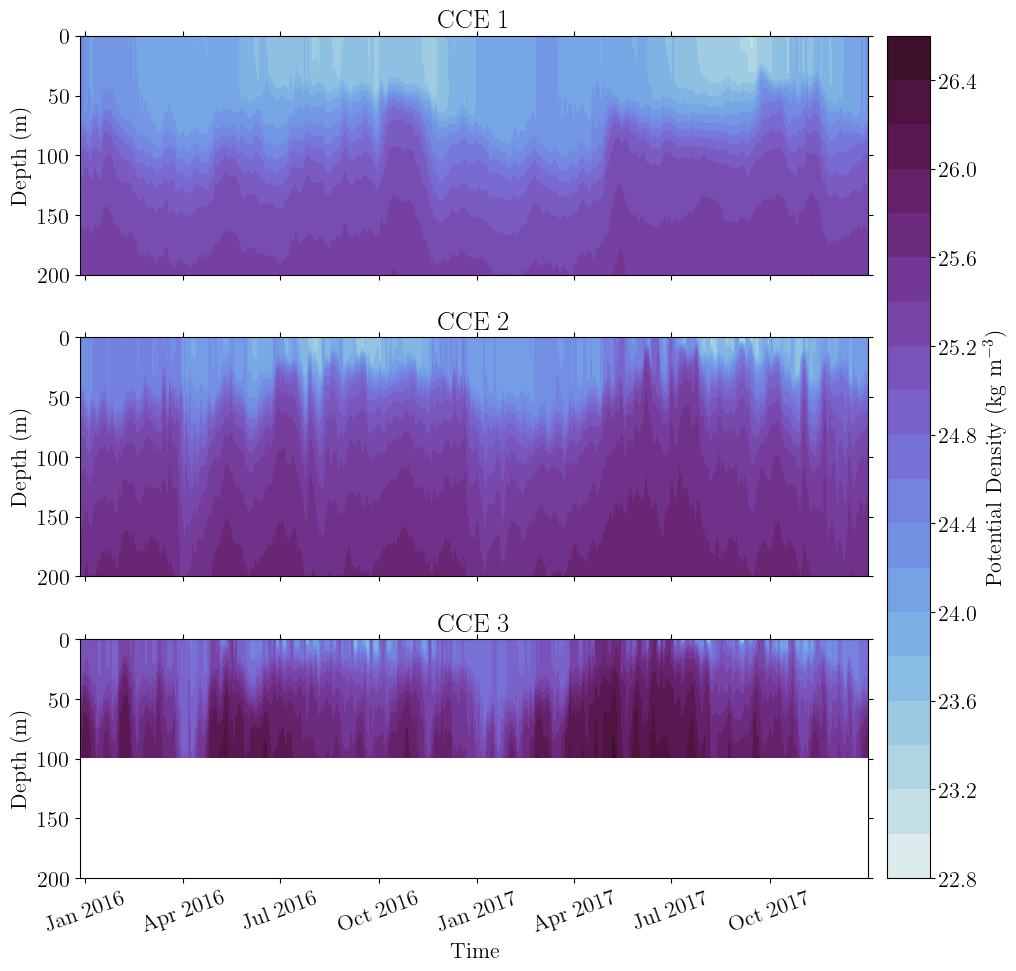

In [5]:
# Set the fontsize
plt.rcParams.update({'font.size': fontsize})

# Set plotting parameters
if option_var == 'temp':
    label = r'Conservative Temperature (deg C)'
    cmap = cmo.thermal
elif option_var == 'sal':
    label = r'Absolute Salinity (g/kg)'
    cmap = cmo.haline
elif option_var == 'density': 
    label = r'Potential Density (kg m$^{-3}$)'
    cmap = cmo.dense
elif option_var == 'u_along': 
    label = r'Along-shelf Velocity (ms$^{-1}$)'
    cmap = cmo.balance
elif option_var == 'v_cross': 
    label = r'Cross-shelf Velocity (ms$^{-1}$)'
    cmap = cmo.balance

# Create figure
fig,axes = plt.subplots(3,1,figsize=(12, 10))
ax1,ax2,ax3 =  axes.flatten()

# Loop through axes
for i, ax in enumerate(axes):

    # Plot temperature
    if (option_var == 'u_along') | (option_var == 'v_cross'): 
        cf = ax.contourf(time_dt,abs(depth),data[i,:,:].T, levels=20, cmap=cmap, vmin=-1.2, vmax=1.2)
    else:
        cf = ax.contourf(time_dt,abs(depth),data[i,:,:].T, levels=20, cmap=cmap)

    # Set axis attributes
    ax.set_title(f"CCE {i+1}")
    ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.set_ylabel("Depth (m)")
    ax.tick_params(top=True, bottom=True, left=True, right=True,
                   direction='out', length=3.5)
    plt.setp(ax.get_xticklabels(), rotation=20)
    if (i == 0) | (i == 1):
        ax.set_xticklabels([])
    if i == 2:
        ax.set_xlabel("Time")

# Adjust layout before adding colorbar
plt.tight_layout()
fig.subplots_adjust(right=0.87)  # Make space on the right side

# Add shared colorbar
cbar = fig.colorbar(cf, ax=axes, location='right', pad=0.02)
cbar.set_label(label)

# Show figure
plt.show()

## **Section 1**: Compute temporal decorrelation scale over the full 2-year period 

In [8]:
# Set parameters
nsite,ntime,ndepth = np.shape(data)
lag = ntime                                                  # Specifies the number of lags in the autocorrelation function
w1, w2 = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Specifies the radian Frequency for annual and semi-annual cycles. Units: rad/sec
M = 20                                                       # Specifies number of windows to divide the data into for the Welch method
p = ntime // M                                               # Specifies window length, i.e., number of data points in each segment
nfft = (p // 2 + 1) if (p % 2 == 0) else ((p - 1) // 2)      # Specifies number of positive frequency bins in the resulting power spectrum
units = 'Hz'                                                 # Specifies the units of the frequency vector 
dt = 1 * (24/1)
norm = 1

# Compute scales array for variance analysis and convert to hours (number of samples)
scales_days = np.logspace(np.log10(0.5),np.log10(365),40)    # units: days
if option_bin == 0:
    scales = scales_days*24                                      # units: # of samples
else: 
    scales = scales_days*2                                       # units: # of samples

# Convert to interger values 
nscales = len(scales)
scales_int = np.array([int(scales[i]) for i in range(nscales)])

# Define frequency range for slope fitting (sub-interial and super-inertial)
fmin_sub = 6*10**(-2) 
fmax_sub = 6*10**(-1) 
fmin_sup = 2*10**(0)
fmax_sup = 1.25*10**(1)

# Compute the elapsed time from beginning of time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

#-------------------------------------------------------#
# CCE 1 Mooring
#-------------------------------------------------------#
print(f'\nCCE1 Mooring')

# Initialize arrays 
autocorr1        = np.zeros((ntime,ndepth))
struct1          = np.zeros((ntime,ndepth))
time_scale1      = np.zeros((ntime,ndepth))
Lt1              = np.zeros((ndepth))
S1               = np.zeros((nfft,ndepth))
CI1              = np.zeros((nfft,2,ndepth))
S1_slope_sub     = np.zeros((ndepth))
S1_slope_unc_sub = np.zeros((ndepth))
S1_slope_sup     = np.zeros((ndepth))
S1_slope_unc_sup = np.zeros((ndepth))
S1_slope_tot     = np.zeros((ndepth))
S1_slope_unc_tot = np.zeros((ndepth))
meanPeriod1      = np.zeros((ndepth))
V1               = np.zeros((nscales,ndepth))
L1               = np.zeros((nscales,ndepth))
p1               = np.zeros((ndepth))
rms1             = np.zeros((ndepth))
fve1             = np.zeros((ndepth))
data1_prime      = np.ma.masked_all((ntime, ndepth))

# Set counter
cn_depth = 0 

# Loop through depths 
for idepth in range(0,ndepth):

    # Set progress bar
    progress = (idepth) / (len(depth))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()
            
    # Initialize the ith depth time series 
    data_ts = data[0,:,idepth]

    # Skip depth if all values are masked
    if np.all(data_ts.mask):
        continue

    # Compute annual and semi-annual cycle
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)

    # Compute the fraction of variance explained and residual
    data1_prime[:,idepth], rms1[idepth], fve1[idepth], _, _ = compute_amp_phase(data_ts, hfit, x_data, parameters = 2)

    # Set time series for the autocorrelation and spectral analysis 
    if (option_var == 'temp') & (option_var == 'sal') & (option_var == 'density') : 

        # Use anomaly time series with annual and semi-annual cycles removed (only for temperature, salinity, and density which have significant seasonality)
        data_n = data1_prime[:,idepth]
    
    else: 

        # Use unprocessed time series 
        data_n = data_ts

    # Detrend time series 
    data_dt = detrend(data_n, time_elapsed, mean = 0) 

    # Compute autocorrelation function
    autocorr1[:,cn_depth], _, _, _, time_scale1[:,cn_depth], _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, norm)

    # Compute the decorrelation scale
    Lt1[cn_depth] = compute_decor_scale_optimize(autocorr1[:,cn_depth],time_scale1[:,cn_depth],T,'unbiased',norm)

    # Compute frequency power spectrum 
    data_interp = np.interp(time_elapsed, time_elapsed[~data_dt.mask], data_dt[~data_dt.mask])
    S1[:,cn_depth], f1, CI1[:,:,cn_depth], _ = spectrum1D_frequency(data_interp, T, M, units)

    # Compute the mean period
    f_zero = f1[f1 > 0]
    S_zero = S1[f1 > 0,cn_depth]
    spectral_centroid = np.trapezoid(f_zero * S_zero, f_zero) / np.trapezoid(S_zero, f_zero)
    meanPeriod1[cn_depth] = (1 / spectral_centroid) * (1/(60*60*24))    # Units: days

    # Compute the sub-inertial and super inertial spectral slope
    f_cpd = f1*(60)*(60)*(24)
    S1_slope_sub[cn_depth], S1_slope_unc_sub[cn_depth], S1_fit_sub, f_range_sub = spectral_slope(f_cpd, S1[:,cn_depth], fmin_sub, fmax_sub)
    S1_slope_sup[cn_depth], S1_slope_unc_sup[cn_depth], S1_fit_sup, f_range_sup = spectral_slope(f_cpd, S1[:,cn_depth], fmin_sup, fmax_sup)
    S1_slope_tot[cn_depth], S1_slope_unc_tot[cn_depth], S1_fit_tot, f_range_tot = spectral_slope(f_cpd, S1[:,cn_depth], fmin_sub, fmax_sup)

    # Plot Spectral slope 
    if option_plot == True: 
            
            plt.figure(figsize=(8, 5))
            plt.loglog(f_cpd, S1[:,cn_depth], label='PSD')
            plt.loglog(f_range_sub, S1_fit_sub, '--r', label=f'Fit: slope = {S1_slope_sub[cn_depth]:.2f} ± {S1_slope_unc_sub[cn_depth]:.2f}')
            plt.loglog(f_range_sup, S1_fit_sup, '--b', label=f'Fit: slope = {S1_slope_sup[cn_depth]:.2f} ± {S1_slope_unc_sup[cn_depth]:.2f}')
            plt.xlabel('Frequency [Hz]')
            plt.ylabel('PSD')
            plt.title('Spectral Slope Test')
            plt.legend()
            plt.grid(True, which='both', ls='--')
            plt.tight_layout()
            plt.show()

    # Compute structure function
    #struct1[:,cn_depth], _ = compute_structure_function(data_ts_m, lag, orders=[1, 2, 3, 4])

    # Compute scale variance and patchiness
    L1[:,cn_depth], V1[:,cn_depth], p1[cn_depth], _ = variance_scale_analysis_1D(data_dt, scales=scales_int, fit_range=None, overlap=0.0, return_windows=False)

    # Set longitude counter
    cn_depth = cn_depth + 1

# Convert time scale to units of days
Lt1_days = Lt1*(1/60)*(1/60)*(1/24)

#-------------------------------------------------------#
# CCE 2 Mooring
#-------------------------------------------------------#
print(f'\nCCE2 Mooring')

# Initialize arrays 
autocorr2        = np.zeros((ntime,ndepth))
struct2          = np.zeros((ntime,ndepth))
time_scale2      = np.zeros((ntime,ndepth))
Lt2              = np.zeros((ndepth))
S2               = np.zeros((nfft,ndepth))
CI2              = np.zeros((nfft,2,ndepth))
S2_slope_sub     = np.zeros((ndepth))
S2_slope_unc_sub = np.zeros((ndepth))
S2_slope_sup     = np.zeros((ndepth))
S2_slope_unc_sup = np.zeros((ndepth))
S2_slope_tot     = np.zeros((ndepth))
S2_slope_unc_tot = np.zeros((ndepth))
meanPeriod2      = np.zeros((ndepth))
V2               = np.zeros((nscales,ndepth))
L2               = np.zeros((nscales,ndepth))
p2               = np.zeros((ndepth))
rms2             = np.zeros((ndepth))
fve2             = np.zeros((ndepth))
data2_prime      = np.ma.masked_all((ntime, ndepth))

# Set counter
cn_depth = 0 

# Loop through depths 
for idepth in range(0,ndepth):

    # Set progress bar
    progress = (idepth) / (len(depth))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()
            
    # Initialize the ith depth time series 
    data_ts = data[1,:,idepth]

    # Skip depth if all values are masked
    if np.all(data_ts.mask):
        continue

    # Remove annual and semi-annual cycle 
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
    data_ts_rm = data_ts - hfit

    # Compute annual and semi-annual cycle
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)

    # Compute the fraction of variance explained and residual
    data2_prime[:,idepth], rms2[idepth], fve2[idepth], _, _ = compute_amp_phase(data_ts, hfit, x_data, parameters = 2)

    # Set time series for the autocorrelation and spectral analysis 
    if (option_var == 'temp') & (option_var == 'sal') & (option_var == 'density') : 

        # Use anomaly time series with annual and semi-annual cycles removed (only for temperature, salinity, and density which have significant seasonality)
        data_n = data2_prime[:,idepth]

    else: 

        # Use unprocessed time series 
        data_n = data_ts

    # Detrend data record 
    data_dt = detrend(data_n, time_elapsed, mean = 0)

    # Compute autocorrelation function
    autocorr2[:,cn_depth], _, _, _, time_scale2[:,cn_depth], _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, 0)

    # Compute the decorrelation scale
    Lt2[cn_depth] = compute_decor_scale_optimize(autocorr2[:,cn_depth],time_scale1[:,cn_depth],T,'unbiased',0)

    # Compute frequency power spectrum 
    data_interp = np.interp(time_elapsed, time_elapsed[~data_dt.mask], data_dt[~data_dt.mask])
    S2[:,cn_depth], f2, CI2[:,:,cn_depth], _ = spectrum1D_frequency(data_interp, T, M, units)

    # Compute the mean period
    f_zero = f2[f2 > 0]
    S_zero = S2[f2 > 0,cn_depth]
    spectral_centroid = np.trapezoid(f_zero * S_zero, f_zero) / np.trapezoid(S_zero, f_zero)
    meanPeriod2[cn_depth] = (1 / spectral_centroid) * (1/(60*60*24))    # Units: days

    # Compute the sub-inertial and super inertial spectral slope
    f_cpd = f2*(60)*(60)*(24)
    S2_slope_sub[cn_depth], S2_slope_unc_sub[cn_depth], S2_fit_sub, f_range_sub = spectral_slope(f_cpd, S2[:,cn_depth], fmin_sub, fmax_sub)
    S2_slope_sup[cn_depth], S2_slope_unc_sup[cn_depth], S2_fit_sup, f_range_sup = spectral_slope(f_cpd, S2[:,cn_depth], fmin_sup, fmax_sup)
    S2_slope_tot[cn_depth], S2_slope_unc_tot[cn_depth], S2_fit_tot, f_range_tot = spectral_slope(f_cpd, S2[:,cn_depth], fmin_sub, fmax_sup)

    # Compute structure function
    #struct2[:,cn_depth], _ = compute_structure_function(data_ts_m, lag, orders=[1, 2, 3, 4])

    # Compute scale variance and patchiness
    L2[:,cn_depth], V2[:,cn_depth], p2[cn_depth], _ = variance_scale_analysis_1D(data_dt, scales=scales_int, fit_range=None, overlap=0.0, return_windows=False)

    # Set longitude counter
    cn_depth = cn_depth + 1

# Convert time scale to units of days
Lt2_days = Lt2*(1/60)*(1/60)*(1/24)

#-------------------------------------------------------#
# CCE 3 Mooring
#-------------------------------------------------------#
print(f'\nCCE3 Mooring')

# Initialize arrays 
autocorr3        = np.zeros((ntime,ndepth))
struct3          = np.zeros((ntime,ndepth))
time_scale3      = np.zeros((ntime,ndepth))
Lt3              = np.zeros((ndepth))
S3               = np.zeros((nfft,ndepth))
CI3              = np.zeros((nfft,2,ndepth))
S3_slope_sub     = np.zeros((ndepth))
S3_slope_unc_sub = np.zeros((ndepth))
S3_slope_sup     = np.zeros((ndepth))
S3_slope_unc_sup = np.zeros((ndepth))
S3_slope_tot     = np.zeros((ndepth))
S3_slope_unc_tot = np.zeros((ndepth))
meanPeriod3      = np.zeros((ndepth))
V3               = np.zeros((nscales,ndepth))
L3               = np.zeros((nscales,ndepth))
p3               = np.zeros((ndepth))
rms3             = np.zeros((ndepth))
fve3             = np.zeros((ndepth))
data3_prime      = np.ma.masked_all((ntime, ndepth))

# Set counter
cn_depth = 0 

# Loop through depths 
for idepth in range(0,ndepth):

    # Set progress bar
    progress = (idepth) / (len(depth))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()
            
    # Initialize the ith depth time series 
    data_ts = data[2,:,idepth]

    # Skip depth if all values are masked
    if np.all(data_ts.mask):
        continue

    # Compute annual and semi-annual cycle
    hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)

    # Compute the fraction of variance explained and residual
    data3_prime[:,idepth], rms3[idepth], fve3[idepth], _, _ = compute_amp_phase(data_ts, hfit, x_data, parameters = 2)

    # Set time series for the autocorrelation and spectral analysis 
    if (option_var == 'temp') & (option_var == 'sal') & (option_var == 'density') : 

        # Use anomaly time series with annual and semi-annual cycles removed (only for temperature, salinity, and density which have significant seasonality)
        data_n = data3_prime[:,idepth]

    else: 

        # Use unprocessed time series 
        data_n = data_ts

    # Detrend data record 
    data_dt = detrend(data_n, time_elapsed, mean = 0)

    # Compute autocorrelation function
    autocorr3[:,cn_depth], _, _, _, time_scale3[:,cn_depth], _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, 0)

    # Compute the decorrelation scale
    Lt3[cn_depth] = compute_decor_scale_optimize(autocorr3[:,cn_depth],time_scale3[:,cn_depth],T,'unbiased',0)

    # Compute frequency power spectrum 
    data_interp = np.interp(time_elapsed, time_elapsed[~data_dt.mask], data_dt[~data_dt.mask])
    S3[:,cn_depth], f3, CI3[:,:,cn_depth], _ = spectrum1D_frequency(data_interp, T, M, units)

    # Compute the mean period
    f_zero = f3[f3 > 0]
    S_zero = S3[f1 > 0,cn_depth]
    spectral_centroid = np.trapezoid(f_zero * S_zero, f_zero) / np.trapezoid(S_zero, f_zero)
    meanPeriod3[cn_depth] = (1 / spectral_centroid) * (1/(60*60*24))    # Units: days

    # Compute the sub-inertial and super inertial spectral slope
    f_cpd = f3*(60)*(60)*(24)
    S3_slope_sub[cn_depth], S3_slope_unc_sub[cn_depth], S3_fit_sub, f_range_sub = spectral_slope(f_cpd, S3[:,cn_depth], fmin_sub, fmax_sub)
    S3_slope_sup[cn_depth], S3_slope_unc_sup[cn_depth], S3_fit_sup, f_range_sup = spectral_slope(f_cpd, S3[:,cn_depth], fmin_sup, fmax_sup)
    S3_slope_tot[cn_depth], S3_slope_unc_tot[cn_depth], S3_fit_tot, f_range_tot = spectral_slope(f_cpd, S3[:,cn_depth], fmin_sub, fmax_sup)

    # Compute structure function
    #struct3[:,cn_depth], _ = compute_structure_function(data_ts_m, lag, orders=[1, 2, 3, 4])

    # Compute scale variance and patchiness
    L3[:,cn_depth], V3[:,cn_depth], p3[cn_depth], _ = variance_scale_analysis_1D(data_dt, scales=scales_int, fit_range=None, overlap=0.0, return_windows=False)

    # Set longitude counter
    cn_depth = cn_depth + 1

# Convert time scale to units of days
Lt3_days = Lt3*(1/60)*(1/60)*(1/24)

# Mask fill values (zeros)
Lt1_days_m = np.ma.masked_where(Lt1_days == 0, Lt1_days)
Lt2_days_m = np.ma.masked_where(Lt2_days == 0, Lt2_days)
Lt3_days_m = np.ma.masked_where(Lt3_days == 0, Lt3_days)
fve1_m = np.ma.masked_where(fve1 == 0, fve1)
fve2_m = np.ma.masked_where(fve2 == 0, fve2)
fve3_m = np.ma.masked_where(fve3 == 0, fve3)


CCE1 Mooring
Progress: 98.9%
CCE2 Mooring
Progress: 98.9%
CCE3 Mooring
Progress: 98.9%

Compute the mean and variance depth profile for the data

In [9]:
# Set the number of time steps
_,ntime,_ = np.shape(data)

# Compute the time mean, standard deviation, and variance profiles for each site
mean_profile = np.ma.mean(data,axis=1) 
std_profile = np.ma.std(data,axis=1,ddof=1)
var_profile = np.ma.var(data,axis=1,ddof=1)
var1_anomaly_profile = np.ma.var(data1_prime,axis=0,ddof=1)
var2_anomaly_profile = np.ma.var(data2_prime,axis=0,ddof=1)
var3_anomaly_profile = np.ma.var(data3_prime,axis=0,ddof=1)

# Compute the number of degrees of freedom at each site
if option_bin == 0:
    T_days = T*(1/60)*(1/60)*(1/24)
else:
    T_days = T*(1/60)*(1/60)*(1/2)
n_d1, n_d2, n_d3 = Lt1_days_m/T_days, Lt2_days_m/T_days, Lt3_days_m/T_days
Neff1 = ntime/(n_d1)
Neff2 = ntime/(n_d2)
Neff3 = ntime/(n_d3)

# Compute the standard error of the mean and variance
stdm1_profile = std_profile[0,:]/np.sqrt(Neff1)
stdm2_profile = std_profile[1,:]/np.sqrt(Neff2)
stdm3_profile = std_profile[2,:]/np.sqrt(Neff3)

stdv1_profile = var_profile[0,:] * np.sqrt(2/(Neff1-1))
stdv2_profile = var_profile[1,:] * np.sqrt(2/(Neff2-1))
stdv3_profile = var_profile[2,:] * np.sqrt(2/(Neff3-1))

stdv1_anomaly_profile = var1_anomaly_profile * np.sqrt(2/(Neff1-1))
stdv2_anomaly_profile = var2_anomaly_profile * np.sqrt(2/(Neff2-1))
stdv3_anomaly_profile = var3_anomaly_profile * np.sqrt(2/(Neff3-1))

## **Section 2**: Compute the mixed layer depth as a function of time 

In [10]:
if option_var == 'density':
    
    ################################################################################
    #--- Mixed Layer Depth Calculation ---#
    ################################################################################    

    # Set parameters
    n_moor, n_time, n_depth = data.shape
    phi = 100  # Units: J/m^2
    g = 9.81   # Units: m/s^2

    # Initialize arrays 
    mld_THRESH = np.ma.masked_all((n_moor, n_time))
    mld_GRAD   = np.ma.masked_all((n_moor, n_time))
    mld_PE     = np.ma.masked_all((n_moor, n_time))

    # Loop over moorings 
    for imoor in range(n_moor):

        # Print state for ith mooring
        print(f'Computing MLD for mooring {imoor+1}/{data.shape[0]} ...')
        
        # Loop over time
        for it in range(n_time):

            # Extract density profile at this mooring and time
            rho_prof = data[imoor, it, :]
            
            # Skip fully masked profiles
            if rho_prof.mask.all():
                continue
            
            # Compute MLD using the potential energy anomaly method
            mld_THRESH[imoor, it] = compute_mld(abs(depth), density=rho_prof, method='threshold', dSigma=0.03, zref=10)
            mld_GRAD[imoor, it]   = compute_mld(abs(depth), density=rho_prof, method='gradient', gradSigma=0.009)
            mld_PE[imoor, it]     = compute_mld(abs(depth), density=rho_prof, method='potential_energy', phi=200)

    # Mask invalid or missing values
    mld_THRESH = np.ma.masked_invalid(mld_THRESH)
    mld_GRAD   = np.ma.masked_invalid(mld_GRAD)
    mld_PE     = np.ma.masked_invalid(mld_PE)

    # Compute the mean variance in the mixed layer depth at each mooring site
    mld_m = np.ma.mean(mld_PE,axis=1)
    mld_var = np.ma.var(mld_PE,axis=1,ddof=1)

Computing MLD for mooring 1/3 ...
Computing MLD for mooring 2/3 ...
Computing MLD for mooring 3/3 ...


Compute a monthly climatology of mixed layer depths

In [11]:
if option_var == 'density':

    # Convert time array to year and month integers
    years  = np.array([t.year for t in time_dt])
    months = np.array([t.month for t in time_dt])

    # Combine into "year-month" unique identifiers (e.g., 202301 for Jan 2023)
    yearmonth = years * 100 + months
    unique_months = np.unique(yearmonth)

    # Preallocate masked arrays for results
    mld_monthly_mean  = np.ma.masked_all((n_moor, len(unique_months)))
    mld_monthly_var   = np.ma.masked_all((n_moor, len(unique_months)))
    mld_monthly_std   = np.ma.masked_all((n_moor, len(unique_months)))
    mld_monthly_stdm  = np.ma.masked_all((n_moor, len(unique_months)))
    mld_monthly_stdv  = np.ma.masked_all((n_moor, len(unique_months)))
    Lt_days           = np.ma.masked_all((n_moor, len(unique_months)))

    # Loop over moorings and months
    for imoor in range(n_moor):
        for im, ym in enumerate(unique_months):

            # Select all time indices belonging to this month
            idx = np.where(yearmonth == ym)[0]
            if idx.size == 0:
                continue
            
            # Extract MLD values for that mooring and month
            vals = mld_PE[imoor, idx]
            itime = time_elapsed[idx]

            # Skip if all masked
            if vals.mask.all():
                continue

            # Compute monthly mean and variance ignoring masked values
            mld_monthly_mean[imoor, im] = np.ma.mean(vals)
            mld_monthly_var[imoor, im]  = np.ma.var(vals,ddof=1)
            mld_monthly_std[imoor, im]  = np.ma.std(vals,ddof=1)

            # Compute the decorrelation scale 
            vals_dt = detrend(vals, itime, mean = 0)
            autocorr, _, _, _, lag_time, _ = compute_autocorr_optimize(vals_dt, itime, len(itime), 'biased', 0)
            Lt = compute_decor_scale_optimize(autocorr,lag_time,T,'unbiased',0)

            # Convert decorrelation scale to units of days
            Lt_days[imoor,im] = Lt*(1/60)*(1/60)*(1/24)

            # Compute the number of degrees of freedom at each site
            T_days = T*(1/60)*(1/60)*(1/24)
            n_d = Lt_days[imoor,im]/T_days
            N_eff = len(itime)/n_d

            # Compute the standard error of the mean and variance
            mld_monthly_stdm[imoor, im] = mld_monthly_std[imoor, im] / np.sqrt(N_eff)
            mld_monthly_stdv[imoor, im] = mld_monthly_var[imoor, im] * np.sqrt(2/(N_eff-1))

    # Create simple arrays of the corresponding (year, month)
    month_years = unique_months // 100
    month_nums  = unique_months % 100

    # Combine into datetime objects (using the first day of each month)
    monthly_time = np.array([
        datetime(int(y), int(m), 1) for y, m in zip(month_years, month_nums)
    ])

## **Section 3**: Plot quantities from sections 1 and 2

Plot the mean and variance of the mixed layer depth monthly climatology

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/1081142703.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".-k" (-> color='k'). The keyword argument will take precedence.
  ax.plot(monthly_time,mld_monthly_mean[1,:], '.-k', color='tab:red', lw=1)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/1081142703.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".-k" (-> color='k'). The keyword argument will take precedence.
  ax.plot(monthly_time,mld_monthly_mean[2,:], '.-k', color='tab:blue', lw=1)


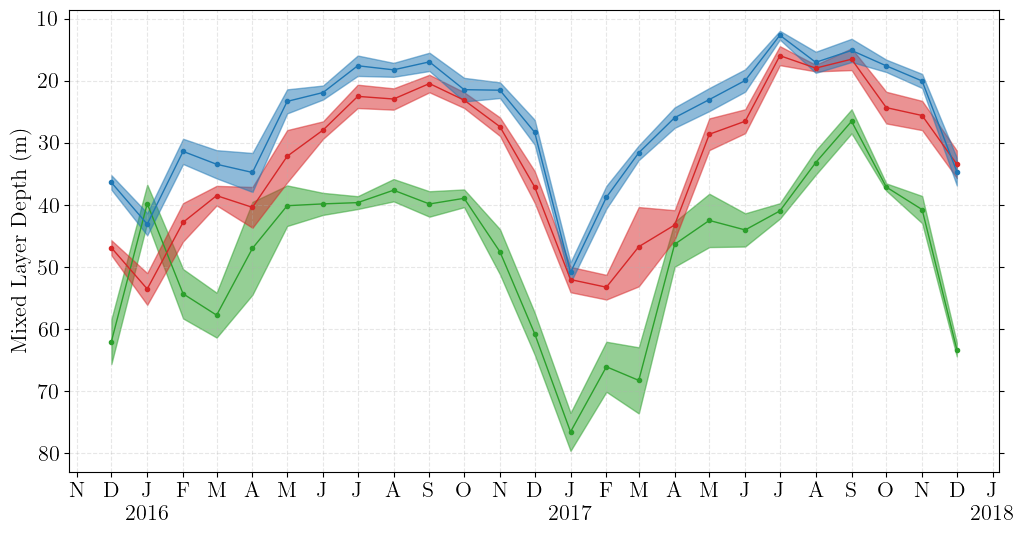

In [10]:
if option_var == 'density':
    
    ################################################################################
    #--- Plot Monthly Mixed Layer Depth Variability ---#
    ################################################################################

    # Create figure
    fig,ax = plt.subplots(figsize=(12, 6))

    # Plot mixed layer depth variance for each mooring
    ax.plot(monthly_time,mld_monthly_mean[0,:], '.-', color='tab:green', lw=1)
    ax.plot(monthly_time,mld_monthly_mean[1,:], '.-k', color='tab:red', lw=1)
    ax.plot(monthly_time,mld_monthly_mean[2,:], '.-k', color='tab:blue', lw=1)

    # Plot standard error of the variance  for each mooring
    ax.fill_between(monthly_time, mld_monthly_mean[0,:] - mld_monthly_stdm[0,:], mld_monthly_mean[0,:] + mld_monthly_stdm[0,:], color='tab:green', alpha=0.5)
    ax.fill_between(monthly_time, mld_monthly_mean[1,:] - mld_monthly_stdm[1,:], mld_monthly_mean[1,:] + mld_monthly_stdm[1,:], color='tab:red', alpha=0.5)
    ax.fill_between(monthly_time, mld_monthly_mean[2,:] - mld_monthly_stdm[2,:], mld_monthly_mean[2,:] + mld_monthly_stdm[2,:], color='tab:blue', alpha=0.5)

    # Set axis attributes
    ax.set_ylabel(r"Mixed Layer Depth (m)")
    ax.tick_params(top=False, bottom=True, left=True, right=True,
                    direction='out', length=3.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))
    ax.grid(True,linestyle='--',alpha=0.3)
    ax.invert_yaxis()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/2962857985.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".-k" (-> color='k'). The keyword argument will take precedence.
  ax.plot(monthly_time,mld_monthly_var[1,:], '.-k', color='tab:red', lw=1)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/2962857985.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".-k" (-> color='k'). The keyword argument will take precedence.
  ax.plot(monthly_time,mld_monthly_var[2,:], '.-k', color='tab:blue', lw=1)


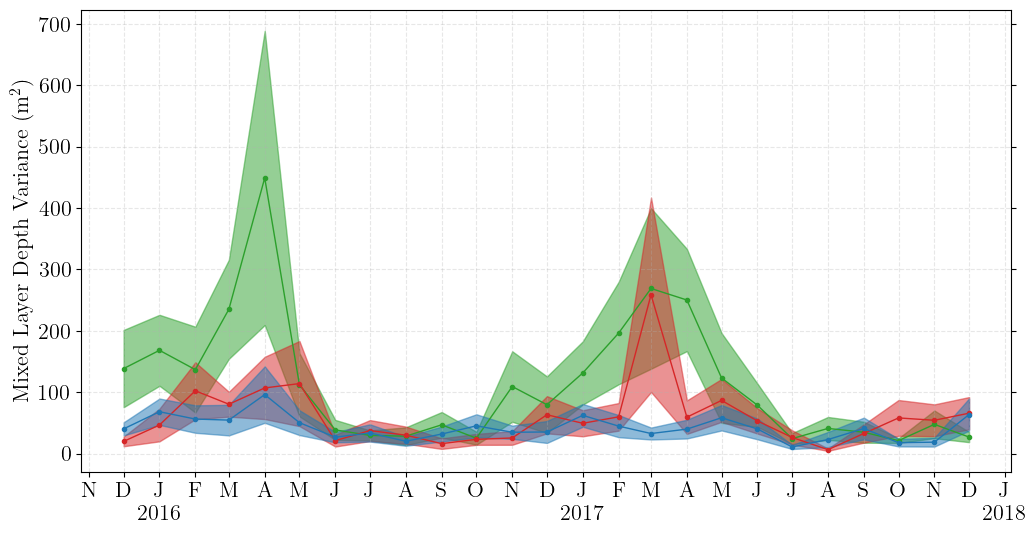

In [11]:
if option_var == 'density':

    ################################################################################
    #--- Plot Monthly Mixed Layer Depth Variability ---#
    ################################################################################

    # Create figure
    fig,ax = plt.subplots(figsize=(12, 6))

    # Plot mixed layer depth variance for each mooring
    ax.plot(monthly_time,mld_monthly_var[0,:], '.-', color='tab:green', lw=1)
    ax.plot(monthly_time,mld_monthly_var[1,:], '.-k', color='tab:red', lw=1)
    ax.plot(monthly_time,mld_monthly_var[2,:], '.-k', color='tab:blue', lw=1)

    # Plot standard error of the variance  for each mooring
    ax.fill_between(monthly_time, mld_monthly_var[0,:] - mld_monthly_stdv[0,:], mld_monthly_var[0,:] + mld_monthly_stdv[0,:], color='tab:green', alpha=0.5)
    ax.fill_between(monthly_time, mld_monthly_var[1,:] - mld_monthly_stdv[1,:], mld_monthly_var[1,:] + mld_monthly_stdv[1,:], color='tab:red', alpha=0.5)
    ax.fill_between(monthly_time, mld_monthly_var[2,:] - mld_monthly_stdv[2,:], mld_monthly_var[2,:] + mld_monthly_stdv[2,:], color='tab:blue', alpha=0.5)

    # Set axis attributes
    ax.set_ylabel(r"Mixed Layer Depth Variance (m$^2$)")
    ax.tick_params(top=False, bottom=True, left=True, right=True,
                    direction='out', length=3.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))
    ax.grid(True,linestyle='--',alpha=0.3)

Plot the model's decorrelation scale at the three locations

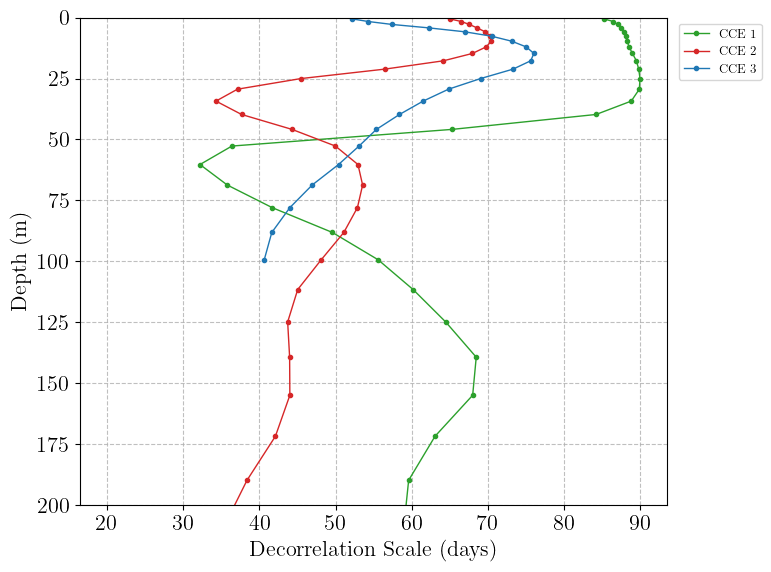

In [12]:
# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the depth-dependent decorrelation time scale
ax.plot(Lt1_days_m, abs(depth), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(Lt2_days_m, abs(depth), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(Lt3_days_m, abs(depth), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Set figure attributes
ax.set_xlabel(r'Decorrelation Scale (days)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot the fraction of variance explained

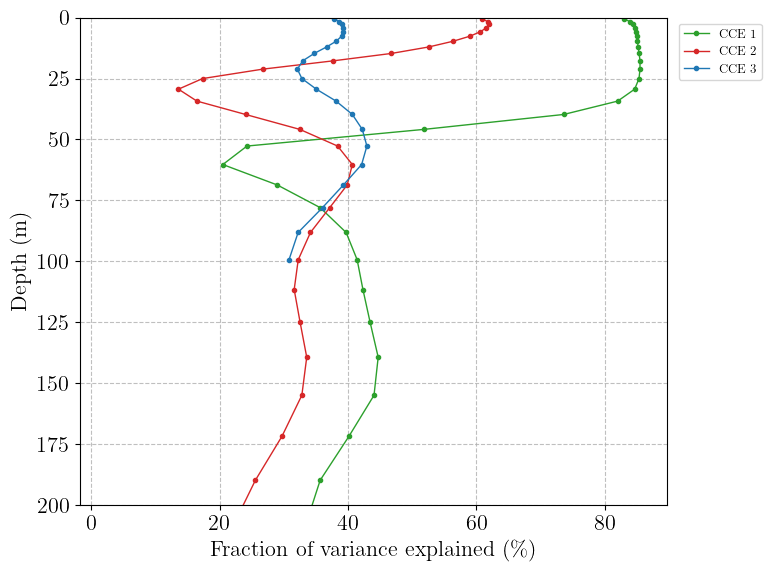

In [13]:
# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the depth-dependent fraction of variance explained 
ax.plot(fve1_m*100, abs(depth), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(fve2_m*100, abs(depth), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(fve3_m*100, abs(depth), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Set figure attributes
ax.set_xlabel(r'Fraction of variance explained (\%)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot the time averaged profiles 

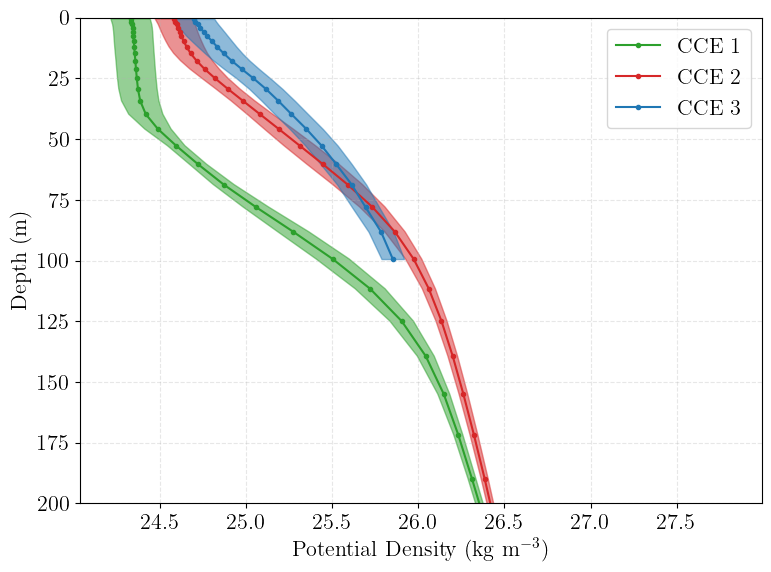

In [14]:
# Create figure
fig,ax = plt.subplots(1,1,figsize=(8, 6))

# Plot mean profiles for each mooring
ax.plot(mean_profile[0,:],abs(depth),'.-',color='tab:green',label='CCE 1')
ax.plot(mean_profile[1,:],abs(depth),'.-',color='tab:red',label='CCE 2')
ax.plot(mean_profile[2,:],abs(depth),'.-',color='tab:blue',label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth), mean_profile[0,:] - stdm1_profile, mean_profile[0,:] + stdm1_profile, color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth), mean_profile[1,:] - stdm2_profile, mean_profile[1,:] + stdm2_profile, color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth), mean_profile[2,:] - stdm3_profile, mean_profile[2,:] + stdm3_profile, color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_xlabel(label)
ax.set_ylabel("Depth (m)")
ax.set_ylim([0,200])
ax.invert_yaxis()
ax.legend()
ax.grid(True,linestyle='--',alpha=0.3)

# Show figure
plt.tight_layout()
plt.show()

Plot the variance profile

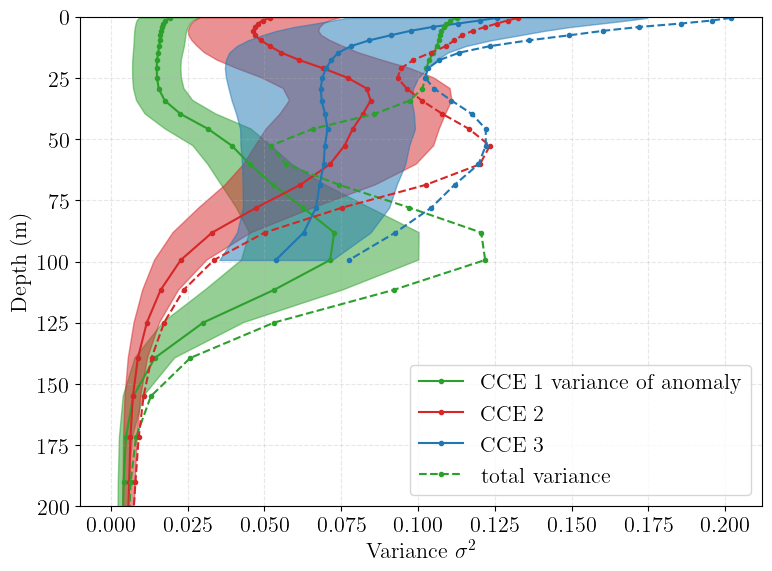

In [15]:
# Create figure
fig,ax = plt.subplots(1,1,figsize=(8, 6))

# Plot mean profiles for each mooring
ax.plot(var1_anomaly_profile,abs(depth),'.-',color='tab:green',label='CCE 1 variance of anomaly')
ax.plot(var2_anomaly_profile,abs(depth),'.-',color='tab:red',label='CCE 2')
ax.plot(var3_anomaly_profile,abs(depth),'.-',color='tab:blue',label='CCE 3')

# Plot mean profiles for each mooring
ax.plot(var_profile[0,:],abs(depth),'.--',color='tab:green', label='total variance')
ax.plot(var_profile[1,:],abs(depth),'.--',color='tab:red')
ax.plot(var_profile[2,:],abs(depth),'.--',color='tab:blue')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth), var1_anomaly_profile - stdv1_anomaly_profile, var1_anomaly_profile + stdv1_anomaly_profile, color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth), var2_anomaly_profile - stdv2_anomaly_profile, var2_anomaly_profile + stdv2_anomaly_profile, color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth), var3_anomaly_profile - stdv3_anomaly_profile, var3_anomaly_profile + stdv3_anomaly_profile, color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_xlabel(r'Variance $\sigma^2$')
ax.set_ylabel("Depth (m)")
ax.set_ylim([0,200])
ax.invert_yaxis()
ax.legend()
ax.grid(True,linestyle='--',alpha=0.3)

# Show figure
plt.tight_layout()
plt.show()

Plot mean period 

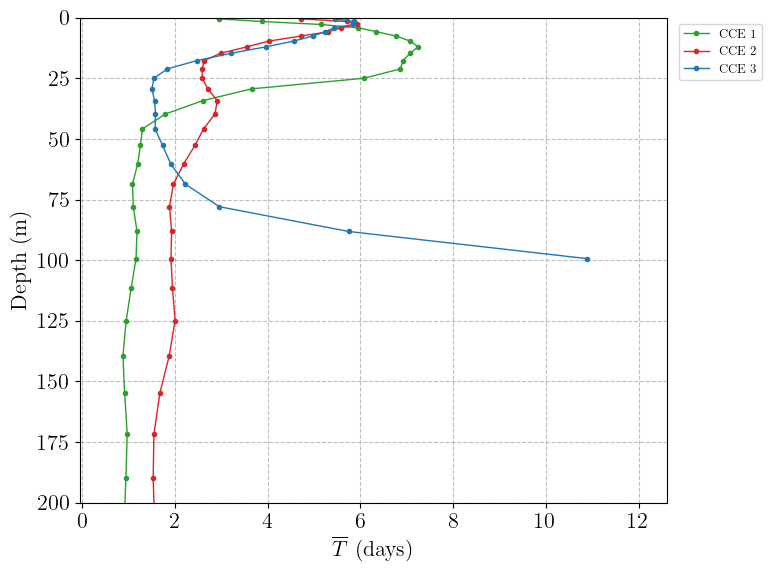

In [16]:
# Mask fill values (zeros)
meanPeriod1_m = np.ma.masked_where(meanPeriod1 == 0, meanPeriod1)
meanPeriod2_m = np.ma.masked_where(meanPeriod2 == 0, meanPeriod2)
meanPeriod3_m = np.ma.masked_where(meanPeriod3 == 0, meanPeriod3)

# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the depth-dependent decorrelation time scale
ax.plot(meanPeriod1_m, abs(depth), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(meanPeriod2_m, abs(depth), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(meanPeriod3_m, abs(depth), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Set figure attributes
ax.set_xlabel(r'$\overline{T}$ (days)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot the temporal variance as a function of scale

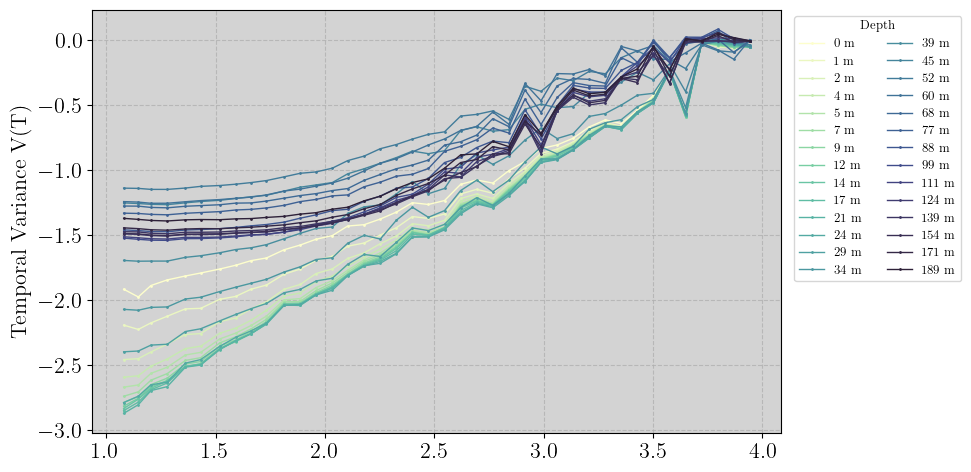

In [17]:
# Convert depth to positive
idx = depth >= -200
depth_pos = abs(depth[idx])

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Set colormap from depths
cmap = cmo.deep
colors = [cmap(i / len(depth_pos)) for i in range(len(depth_pos))]

# Plot each depth
for i, idepth in enumerate(depth_pos):
    ax.plot(np.log10(L1[:,i]), np.log10(V1[:,i]), '.-', label=f"{int(idepth)} m", color=colors[i], linewidth=1, markersize=2)

# Set legend
ax.legend(ncol=2,title="Depth", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,title_fontsize=9)

# Set axis attributes
ax.set_ylabel(r"Temporal Variance V(T)")
ax.grid(True, linestyle='--', alpha=0.8)

# Set the background color of the axes
ax.set_facecolor('lightgray')

# Display figure
plt.tight_layout()
plt.show()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/3485318421.py:28: RuntimeWarning: divide by zero encountered in log10
  contour = ax1.pcolormesh(SC,D,np.log10(V1.T),cmap=cmap,shading='auto')


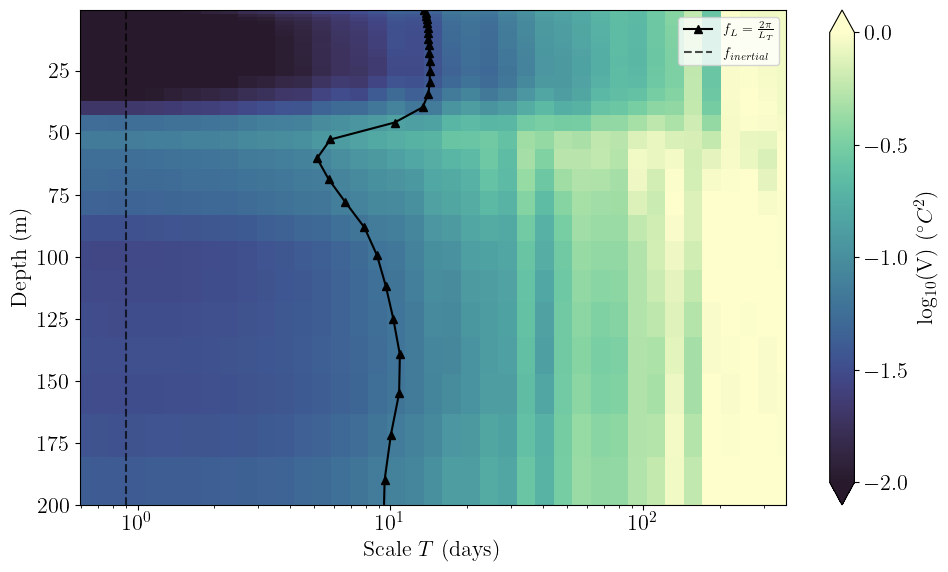

In [18]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
T_decor = Lt1_days_m

# Compute its associated frequency in units of cpd and multiply by 
f_decor = (1/T_decor)*(2*np.pi)

# Compute the interial period in units of cpd
omega = (7.2921*10**(-5))/(2*np.pi)                   # Units: Hz 
f_inertial = 2*omega*np.sin(np.deg2rad(lat[0]))*(86400)  # Units: cpd

# Convert depth to positive
depth_pos = abs(depth)

# Set colormap and levels
cmap = cmo.deep_r
levels= np.arange(-2,2+0.05,0.05)

# Create the figure
fig = plt.figure(figsize=(10, 6))

#--- Subplot #1 ---# 
ax1 = fig.add_subplot(111)

# Create meshgrid and zeros surface 
SC, D = np.meshgrid(scales_days, depth_pos)  

# Plot autocorrelation surface
contour = ax1.pcolormesh(SC,D,np.log10(V1.T),cmap=cmap,shading='auto')

# Overlay decorrelation frequency markers
ax1.plot(1/f_decor, depth_pos, 'k^-', markersize=6, label=r'$f_L = \frac{2\pi}{L_T}$')

# Plot the inertial frequency lines and text
ax1.axvline(1/f_inertial, color='k', linestyle='--', alpha=0.7, label=r'$f_{inertial}$')

# Set figure attributes
ax1.set_xlabel(r'Scale $T$ (days)')
ax1.set_ylabel('Depth (m)')
ax1.set_xscale('log')
ax1.set_xlim(scales_days[1],scales_days[-1])
ax1.set_ylim(depth_pos[0],200)
ax1.legend(loc='upper right',fontsize=10)

# Set color bar
cbar = fig.colorbar(contour,extend='both')
cbar.set_ticks(np.arange(-2,0+0.5,0.5)) 
cbar.set_label(r'log$_{10}$(V) ($^\circ C^2$) ')
contour.set_clim(-2,0)

# Reverse the direction of the x-axis 
ax1.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/2941256572.py:28: RuntimeWarning: divide by zero encountered in log10
  contour = ax1.pcolormesh(SC,D,np.log10(V2.T),cmap=cmap,shading='auto')


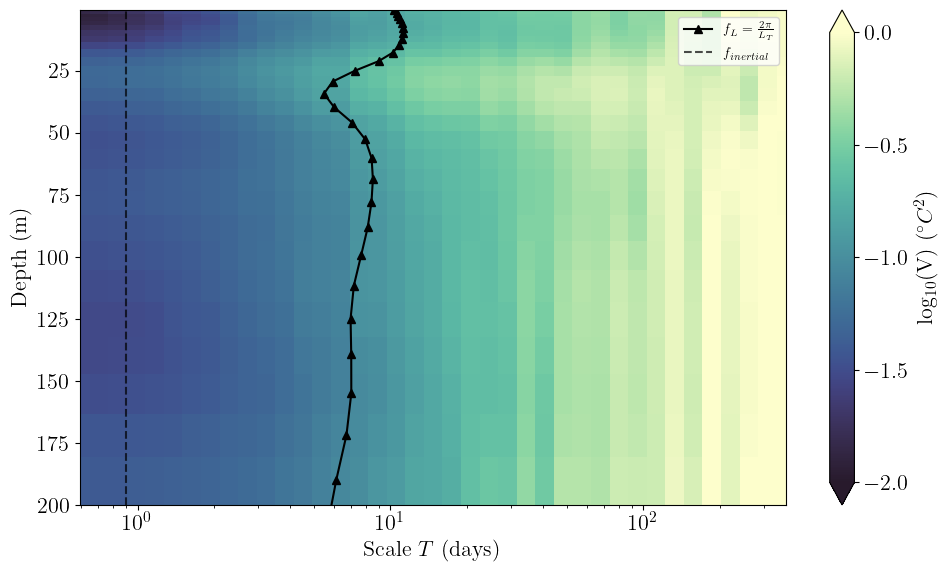

In [19]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
T_decor = Lt2_days_m

# Compute its associated frequency in units of cpd and multiply by 
f_decor = (1/T_decor)*(2*np.pi)

# Compute the interial period in units of cpd
omega = (7.2921*10**(-5))/(2*np.pi)                   # Units: Hz 
f_inertial = 2*omega*np.sin(np.deg2rad(lat[0]))*(86400)  # Units: cpd

# Convert depth to positive
depth_pos = abs(depth)

# Set colormap and levels
cmap = cmo.deep_r
levels= np.arange(-2,2+0.05,0.05)

# Create the figure
fig = plt.figure(figsize=(10, 6))

#--- Subplot #1 ---# 
ax1 = fig.add_subplot(111)

# Create meshgrid and zeros surface 
SC, D = np.meshgrid(scales_days, depth_pos)  

# Plot autocorrelation surface
contour = ax1.pcolormesh(SC,D,np.log10(V2.T),cmap=cmap,shading='auto')

# Overlay decorrelation frequency markers
ax1.plot(1/f_decor, depth_pos, 'k^-', markersize=6, label=r'$f_L = \frac{2\pi}{L_T}$')

# Plot the inertial frequency lines and text
ax1.axvline(1/f_inertial, color='k', linestyle='--', alpha=0.7, label=r'$f_{inertial}$')

# Set figure attributes
ax1.set_xlabel(r'Scale $T$ (days)')
ax1.set_ylabel('Depth (m)')
ax1.set_xscale('log')
ax1.set_xlim(scales_days[1],scales_days[-1])
ax1.set_ylim(depth_pos[0],200)
ax1.legend(loc='upper right',fontsize=10)

# Set color bar
cbar = fig.colorbar(contour,extend='both')
cbar.set_ticks(np.arange(-2,0+0.5,0.5)) 
cbar.set_label(r'log$_{10}$(V) ($^\circ C^2$) ')
contour.set_clim(-2,0)

# Reverse the direction of the x-axis 
ax1.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/3872940837.py:28: RuntimeWarning: divide by zero encountered in log10
  contour = ax1.pcolormesh(SC,D,np.log10(V3.T),cmap=cmap,shading='auto')


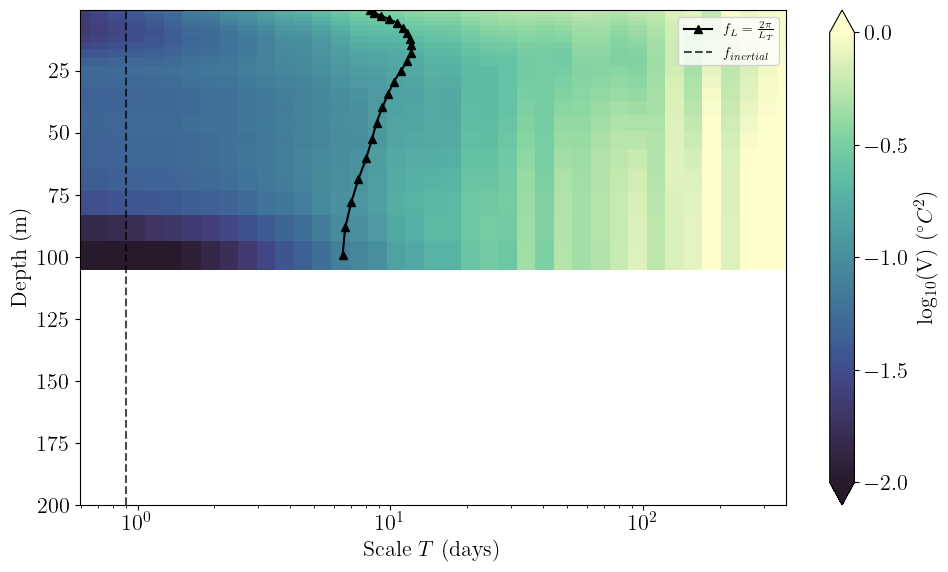

In [20]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
T_decor = Lt3_days_m

# Compute its associated frequency in units of cpd and multiply by 
f_decor = (1/T_decor)*(2*np.pi)

# Compute the interial period in units of cpd
omega = (7.2921*10**(-5))/(2*np.pi)                   # Units: Hz 
f_inertial = 2*omega*np.sin(np.deg2rad(lat[0]))*(86400)  # Units: cpd

# Convert depth to positive
depth_pos = abs(depth)

# Set colormap and levels
cmap = cmo.deep_r
levels= np.arange(-2,2+0.05,0.05)

# Create the figure
fig = plt.figure(figsize=(10, 6))

#--- Subplot #1 ---# 
ax1 = fig.add_subplot(111)

# Create meshgrid and zeros surface 
SC, D = np.meshgrid(scales_days, depth_pos)  

# Plot autocorrelation surface
contour = ax1.pcolormesh(SC,D,np.log10(V3.T),cmap=cmap,shading='auto')

# Overlay decorrelation frequency markers
ax1.plot(1/f_decor, depth_pos, 'k^-', markersize=6, label=r'$f_L = \frac{2\pi}{L_T}$')

# Plot the inertial frequency lines and text
ax1.axvline(1/f_inertial, color='k', linestyle='--', alpha=0.7, label=r'$f_{inertial}$')

# Set figure attributes
ax1.set_xlabel(r'Scale $T$ (days)')
ax1.set_ylabel('Depth (m)')
ax1.set_xscale('log')
ax1.set_xlim(scales_days[1],scales_days[-1])
ax1.set_ylim(depth_pos[0],200)
ax1.legend(loc='upper right',fontsize=10)

# Set color bar
cbar = fig.colorbar(contour,extend='both')
cbar.set_ticks(np.arange(-2,0+0.5,0.5)) 
cbar.set_label(r'log$_{10}$(V) ($^\circ C^2$) ')
contour.set_clim(-2,0)

# Reverse the direction of the x-axis 
ax1.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot the slope of the temporal variance as a function of scale

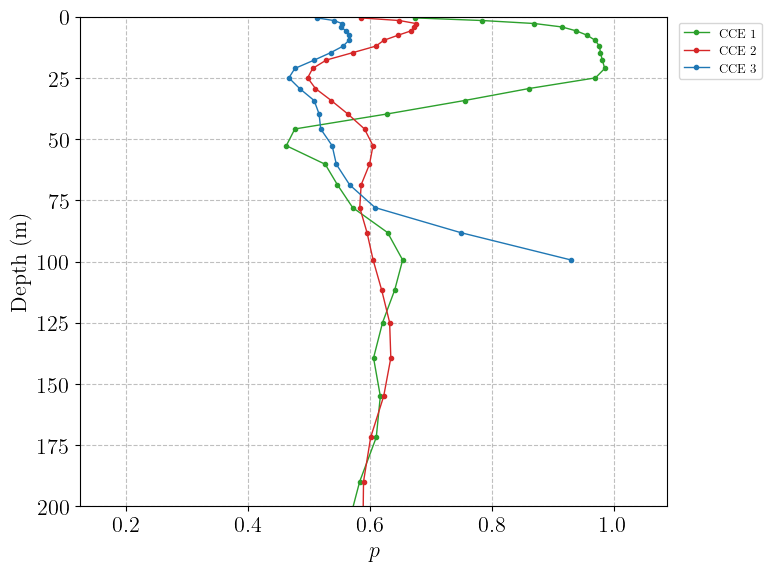

In [21]:
# Mask fill values (zeros)
p1_m = np.ma.masked_where(p1 == 0, p1)
p2_m = np.ma.masked_where(p2 == 0, p2)
p3_m = np.ma.masked_where(p3 == 0, p3)

# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the depth-dependent decorrelation time scale
ax.plot(p1_m, abs(depth), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(p2_m, abs(depth), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(p3_m, abs(depth), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Set figure attributes
ax.set_xlabel(r'$p$')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot the power spectra as a function of depth

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/2250015432.py:31: RuntimeWarning: divide by zero encountered in log10
  contour = ax1.pcolormesh(F,D,np.log10(S1.T),cmap=cmap,shading='auto')


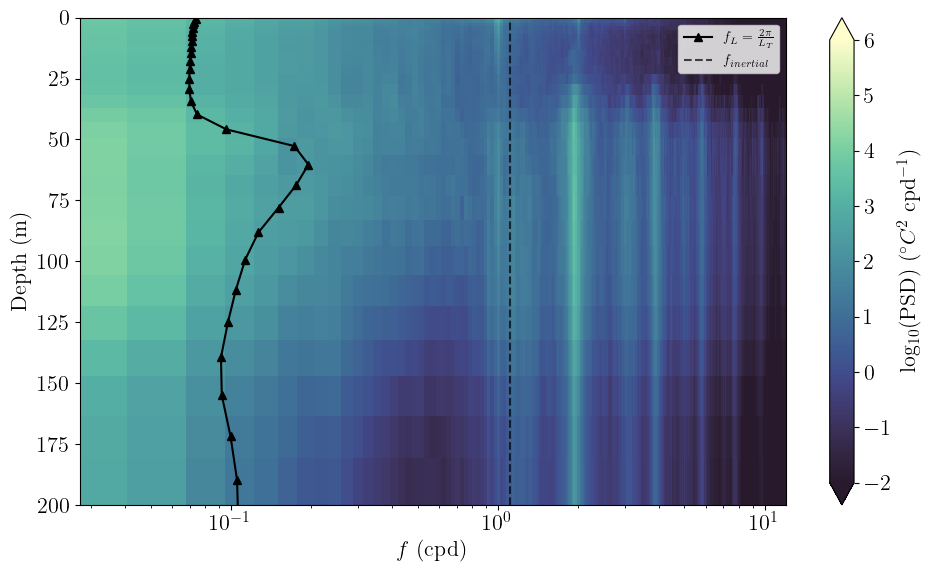

In [22]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
T_decor = Lt1_days_m

# Compute its associated frequency in units of cpd and multiply by 
f_decor = (1/T_decor)*(2*np.pi)

# Compute the interial period in units of cpd
omega = (7.2921*10**(-5))/(2*np.pi)                   # Units: Hz 
f_inertial = 2*omega*np.sin(np.deg2rad(lat[0]))*(86400)  # Units: cpd

# Convert depth to positive
depth_pos = abs(depth)

# Set the fontsize
plt.rcParams.update({'font.size': fontsize})

# Set colormap and levels
cmap = cmo.deep_r
levels=np.arange(-2,6+0.05,0.05)

# Create the figure
fig = plt.figure(figsize=(10, 6))

#--- Subplot #1 ---# 
ax1 = fig.add_subplot(111)

# Create meshgrid and zeros surface 
F, D = np.meshgrid(f_cpd, depth_pos)  

# Plot autocorrelation surface
contour = ax1.pcolormesh(F,D,np.log10(S1.T),cmap=cmap,shading='auto')

# Overlay decorrelation frequency markers
ax1.plot(f_decor, depth_pos, 'k^-', markersize=6, label=r'$f_L = \frac{2\pi}{L_T}$')

# Plot the inertial frequency lines and text
ax1.axvline(f_inertial, color='k', linestyle='--', alpha=0.7, label=r'$f_{inertial}$')

# Set figure attributes
ax1.set_xlabel(r'$f$ (cpd)')
ax1.set_ylabel('Depth (m)')
ax1.set_xscale('log')
ax1.set_ylim(0,200)
ax1.set_xlim(f_cpd[1],f_cpd[-1])
ax1.legend(loc='upper right',fontsize=10)

# Set color bar
cbar = fig.colorbar(contour,extend='both')
cbar.set_ticks(np.arange(-2,6+1,1)) 
cbar.set_label(r'log$_{10}$(PSD) ($^\circ C^2$ cpd$^{-1}$) ')
contour.set_clim(-2,6)

# Reverse the direction of the x-axis 
ax1.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/1201576497.py:31: RuntimeWarning: divide by zero encountered in log10
  contour = ax1.pcolormesh(F,D,np.log10(S2.T),cmap=cmap,shading='auto')


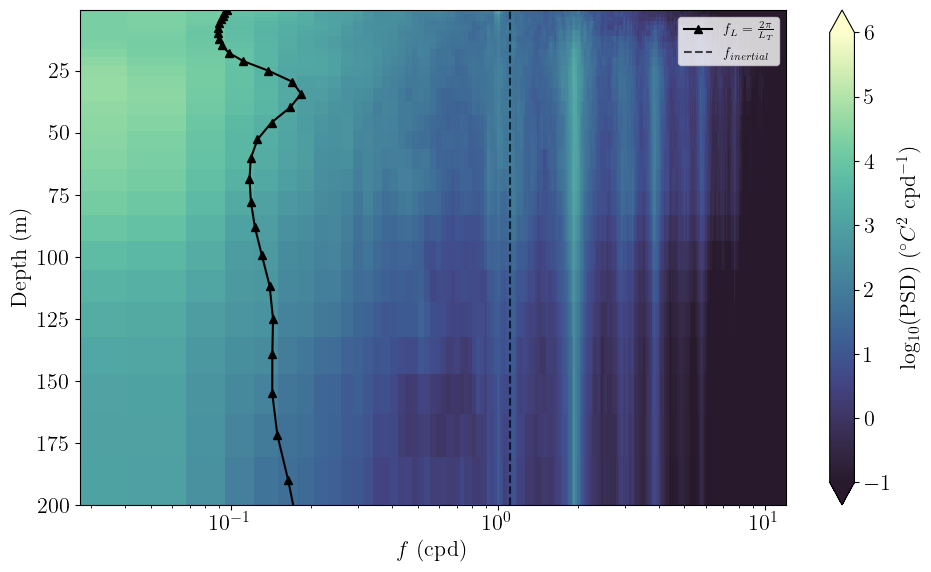

In [23]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
T_decor = Lt2_days_m

# Compute its associated frequency in units of cpd and multiply by 
f_decor = (1/T_decor)*(2*np.pi)

# Compute the interial period in units of cpd
omega = (7.2921*10**(-5))/(2*np.pi)                   # Units: Hz 
f_inertial = 2*omega*np.sin(np.deg2rad(lat[0]))*(86400)  # Units: cpd

# Convert depth to positive
depth_pos = abs(depth)

# Set the fontsize
plt.rcParams.update({'font.size': fontsize})

# Set colormap and levels
cmap = cmo.deep_r
levels=np.arange(-2,6+0.05,0.05)

# Create the figure
fig = plt.figure(figsize=(10, 6))

#--- Subplot #1 ---# 
ax1 = fig.add_subplot(111)

# Create meshgrid and zeros surface 
F, D = np.meshgrid(f_cpd, depth_pos)  

# Plot autocorrelation surface
contour = ax1.pcolormesh(F,D,np.log10(S2.T),cmap=cmap,shading='auto')

# Overlay decorrelation frequency markers
ax1.plot(f_decor, depth_pos, 'k^-', markersize=6, label=r'$f_L = \frac{2\pi}{L_T}$')

# Plot the inertial frequency lines and text
ax1.axvline(f_inertial, color='k', linestyle='--', alpha=0.7, label=r'$f_{inertial}$')

# Set figure attributes
ax1.set_xlabel(r'$f$ (cpd)')
ax1.set_ylabel('Depth (m)')
ax1.set_xscale('log')
ax1.set_xlim(f_cpd[1],f_cpd[-1])
ax1.set_ylim(depth_pos[0],200)
ax1.legend(loc='upper right',fontsize=10)

# Set color bar
cbar = fig.colorbar(contour,extend='both')
cbar.set_ticks(np.arange(-1,6+1,1)) 
cbar.set_label(r'log$_{10}$(PSD) ($^\circ C^2$ cpd$^{-1}$) ')
contour.set_clim(-1,6)

# Reverse the direction of the x-axis 
ax1.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/1584787175.py:31: RuntimeWarning: divide by zero encountered in log10
  contour = ax1.pcolormesh(F,D,np.log10(S3.T),cmap=cmap,shading='auto')


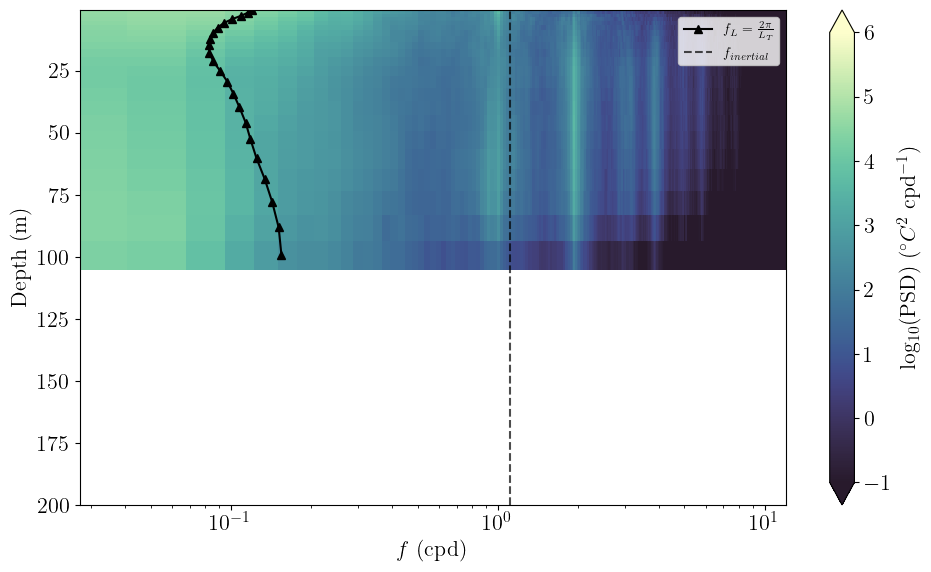

In [24]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
T_decor = Lt3_days_m

# Compute its associated frequency in units of cpd and multiply by 
f_decor = (1/T_decor)*(2*np.pi)

# Compute the interial period in units of cpd
omega = (7.2921*10**(-5))/(2*np.pi)                   # Units: Hz 
f_inertial = 2*omega*np.sin(np.deg2rad(lat[0]))*(86400)  # Units: cpd

# Convert depth to positive
depth_pos = abs(depth)

# Set the fontsize
plt.rcParams.update({'font.size': fontsize})

# Set colormap and levels
cmap = cmo.deep_r
levels=np.arange(-2,6+0.05,0.05)

# Create the figure
fig = plt.figure(figsize=(10, 6))

#--- Subplot #1 ---# 
ax1 = fig.add_subplot(111)

# Create meshgrid and zeros surface 
F, D = np.meshgrid(f_cpd, depth_pos)  

# Plot autocorrelation surface
contour = ax1.pcolormesh(F,D,np.log10(S3.T),cmap=cmap,shading='auto')

# Overlay decorrelation frequency markers
ax1.plot(f_decor, depth_pos, 'k^-', markersize=6, label=r'$f_L = \frac{2\pi}{L_T}$')

# Plot the inertial frequency lines and text
ax1.axvline(f_inertial, color='k', linestyle='--', alpha=0.7, label=r'$f_{inertial}$')

# Set figure attributes
ax1.set_xlabel(r'$f$ (cpd)')
ax1.set_ylabel('Depth (m)')
ax1.set_xscale('log')
ax1.set_xlim(f_cpd[1],f_cpd[-1])
ax1.set_ylim(depth_pos[0],200)
ax1.legend(loc='upper right',fontsize=10)

# Set color bar
cbar = fig.colorbar(contour,extend='both')
cbar.set_ticks(np.arange(-1,6+1,1)) 
cbar.set_label(r'log$_{10}$(PSD) ($^\circ C^2$ cpd$^{-1}$) ')
contour.set_clim(-1,6)

# Reverse the direction of the x-axis 
ax1.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

## Section 4: Compute the monthly mean autocorrelation function and the decorrelation scale for each month 

Compute the autocorrelation function and decorrelation scale for each month in the time series

In [25]:
# Identify unique (year, month) pairs
months = np.array([(t.year, t.month) for t in time_dt])
unique_months = np.unique(months, axis=0)

# Set time and space parameters
if option_bin == 0:                          # Specifies the time interval for model run. Units: seconds
    T            = 1*(60)*(60)               # No binning: 1 hour resolution
else:                  
    T            = 12*(60)*(60)              # Binning: 12 hour resolution

# Dimensions
Nsite, Ntime, Ndepth = data.shape

# Create nested dictionary to hold results: site -> depth -> (year, month)
Lt_var_monthly = {isite: {idepth: {} for idepth in range(Ndepth)} for isite in range(Nsite)}
autocorr_monthly = {isite: {idepth: {} for idepth in range(Ndepth)} for isite in range(Nsite)}
timelag_monthly = {isite: {idepth: {} for idepth in range(Ndepth)} for isite in range(Nsite)}

# Loop over each site
for isite in range(Nsite):
    
    # Loop over each depth
    for idepth in range(Ndepth):
        
        # Extract full time series at this site and depth
        var_series = data[isite, :, idepth]

        # Skip depth if all values are masked
        if np.all(var_series.mask):
            continue

        # Remove seasonal cycle
        hfit_var, *_ = unweighted_lsf(var_series, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
        var_rm = var_series - hfit_var

        # Set a counter
        cn_month = 0

        # Loop over months
        for year, month in unique_months:
            
            # Get data from this month
            month_mask = (months[:, 0] == year) & (months[:, 1] == month)
            time_n = time_elapsed[month_mask]
            var_month = var_rm[month_mask]

            # Skip if too few points or all masked
            if len(time_n) < 10 or (
                np.ma.is_masked(var_month) and var_month.mask.all()
            ):
                continue

            # Detrend
            var_dt = detrend(var_month, time_n, mean=0)

            # Compute autocorrelation and decorrelation scale
            lag = len(time_n)
            autocorr_var, _, _, _, time_scale_var, _ = compute_autocorr_optimize(var_dt, time_n, lag, estimator, 0)
            Lt_var_tmp = compute_decor_scale_optimize(autocorr_var, time_scale_var, T, 'unbiased', 0)

            # Store result in days
            Lt_var_monthly[isite][idepth][(year, month)] = Lt_var_tmp / (60 * 60 * 24)
            autocorr_monthly[isite][idepth][(year, month)] = autocorr_var
            timelag_monthly[isite][idepth][(year, month)] = time_scale_var

Plot the monthly decorrelation scale

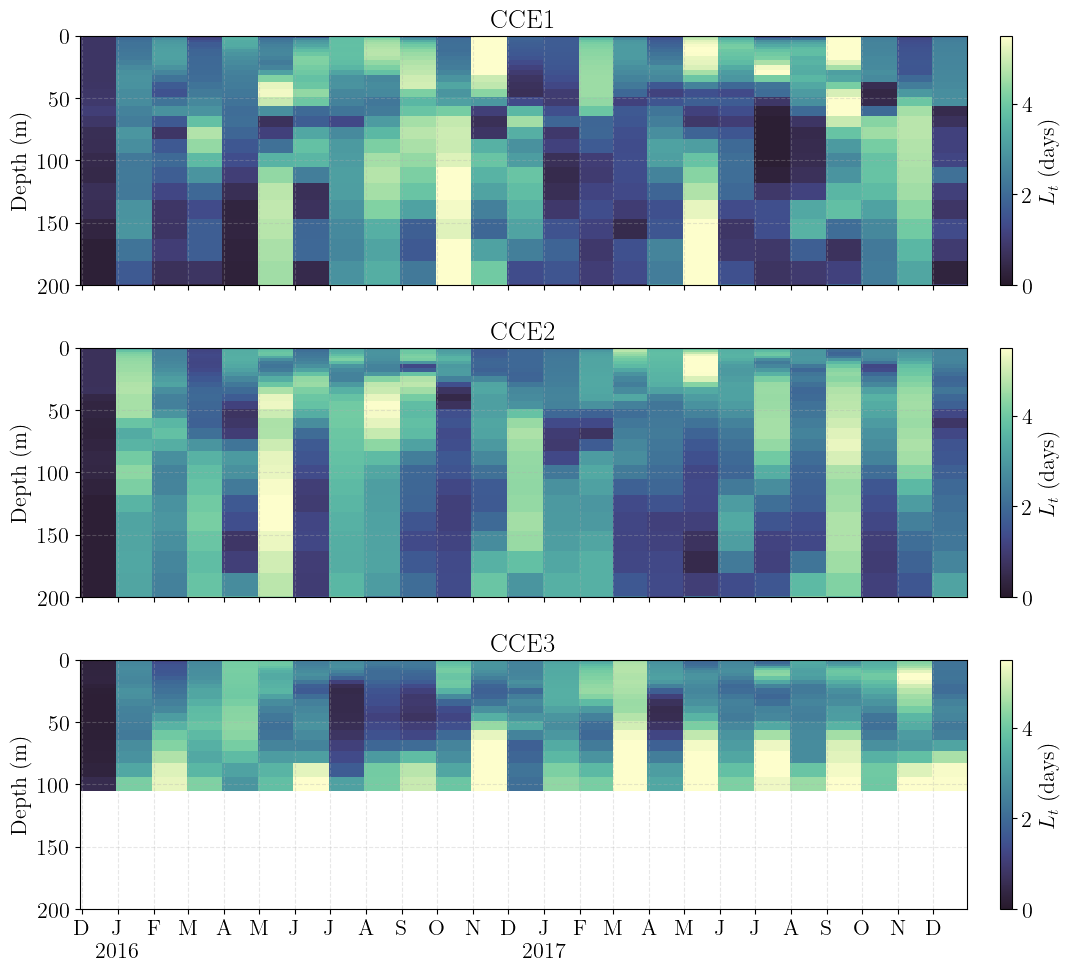

In [26]:
# Step 1: Sort unique (year, month) pairs and convert to datetime
month_datetimes = [datetime(year, month, 15) for (year, month) in unique_months]
sorted_idx = np.argsort(month_datetimes)
month_datetimes_sorted = np.array(month_datetimes)[sorted_idx]
unique_months_sorted = unique_months[sorted_idx]

# Step 2: Create array for plotting
Nmonths = len(unique_months_sorted)
Lt_array = np.full((Nsite, Nmonths, Ndepth), np.nan)  # Use nan for missing data

# Fill array
for isite in range(Nsite):
    for idepth in range(Ndepth):
        for imonth, (year, month) in enumerate(unique_months_sorted):
            if (year, month) in Lt_var_monthly[isite][idepth]:
                Lt_array[isite, imonth, idepth] = Lt_var_monthly[isite][idepth][(year, month)]

# Create list of decorrelation scales for each mooring
data_list = [Lt_array[0,:,:], Lt_array[1,:,:], Lt_array[2,:,:]]

# Set plotting parameters
titles = ['CCE1', 'CCE2', 'CCE3']

# Create figure and axes
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Loop through each subplot to plot each mooring's decorrelation scales with depth 
for ax, title, idata in zip(axes, titles, data_list):

    # Plot decorrelation scale
    mesh = ax.pcolormesh(month_datetimes, depth_pos, idata.T, cmap = cmap, shading='auto',vmin=0, vmax=5.5)

    # Set axis attributes
    ax.set_title(f'{title}')
    ax.set_ylabel('Depth (m)')  
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(0, 200)
    ax.invert_yaxis()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(FuncFormatter(month_fmt))

    # Set colorbar
    cbar = plt.colorbar(mesh, ax=ax, pad=0.03)
    cbar.set_label(r'$L_t$ (days)')

# Display figure
plt.tight_layout()
plt.show()

## Section 5: Compute decorrelation scale and an estimate of its uncertainty

Compute the autocorrelation function for subsampled periods (specify windows length and overlap) within the times series and compute the mean decorrelation scale and its standard error from the mean autocorrelation function

In [6]:
#--- 1D Power Spectrum with the Welch Method ---# 
def spectrum1D_frequency(data, dt, M, units):

    """
    Function for computing the 1D power density spectrum with the Welch method.
    This function is written notationally for time series, but can be applied to spatial data.
    The 1D frequency spectrum is computed by Hanning windowing segments of the data array with 50% overlap.
    
    Parameters
    ----------
    data : Time or spatial data series. Data must be evenly spaced (NaNs must be interpolated).
    dt : Time or spatial interval between measurements.
    M : Number of windows.
    units : 'Hz' (cyclical frequency) or 'rad/s' (radian frequency).
    
    Returns
    -------
    psd : Normalized power spectral density function.
    f : Frequency in units specified by units variable.
    CI : 95% confidence interval.
    variance : Array containing the variance in the time and frequency domains such that variance = np.array([time_domain, frequency_domain])
    """

    # Import libraries
    import numpy as np
    from spectra import spectral_uncer
    from scipy.signal.windows import hann
    from scipy.signal import detrend

    ###########################################################################
    ## STEP #1 - Set fundamental parameters for computing spectrum
    ###########################################################################
    N = len(data)                 # Number of data points of entire time series
    p = N // M                    # Number of data points within a window

    # Compute frequency resolution
    if units == 'Hz':
        df = 1 / (p * dt)
    elif units == 'rad/s':
        df = 2 * np.pi / (p * dt)

    # Compute number of positive frequencies
    if p % 2 == 0:
        L = p // 2 + 1
    else:
        L = (p - 1) // 2

    # Compute the period of the fundamental frequency (lowest frequency)
    T = p * dt

    # Compute frequency vector (units: Hz or rad/s)
    if p % 2 == 0:
        if units == 'Hz':
            f = (1 / T) * np.arange(0, p // 2 + 1)
        elif units == 'rad/s':
            f = (2 * np.pi / T) * np.arange(0, p // 2 + 1)
    else:
        if units == 'Hz':
            f = (1 / T) * np.arange(0, (p - 1) // 2)
        elif units == 'rad/s':
            f = (2 * np.pi / T) * np.arange(0, (p - 1) // 2)

    ###########################################################################
    ## STEP #2 - Segment data with 50% overlap
    ###########################################################################

    # Compute number of segments including 50% overlap
    nseg = M + M - 1     

    # Initialize array for splitting time series into windows with 50% overlap
    data_seg_n = data[:M*p].reshape((p, M), order='F')  # Segment original data set
    data_seg_50 = []

    # Loop through segments
    for iseg in range(M - 1):

        # Obtain segment indicies
        ind_i = int(p * iseg + (p / 2))
        ind_f = int(ind_i + p)

        # Index data and append
        if ind_f <= len(data):
            data_seg_50.append(data[ind_i:ind_f])

    # Concatinate data segements
    if data_seg_50:
        data_seg_50 = np.stack(data_seg_50, axis=1)
        data_seg_n = np.concatenate((data_seg_n, data_seg_50), axis=1)

    ###########################################################################
    ## STEP #3 - Remove linear trend for each segment and apply hanning window
    ###########################################################################

    # Compute a normalized hanning window
    window = hann(p) * np.sqrt(p / np.sum(hann(p)**2))

    # Preallocate windowed detrended segmented data array
    data_seg_w = np.zeros_like(data_seg_n)

    # Loop through segments
    for iseg in range(nseg):

        # Detrend and apply window
        data_seg_w[:, iseg] = detrend(data_seg_n[:, iseg]) * window

    ###########################################################################
    ## STEP #4 - Compute mean 1D frequency spectrum
    ###########################################################################

    # Preallocate arrays
    spec_sum = np.zeros(p)                 # Sspectrum summation array
    cn = np.zeros(p)                       # Counter
    variance = np.zeros(2)                 # Variance in time and frequency domain

    # Loop through segments
    for iseg in range(nseg):

        # Fourier transform data
        fft_data_seg = np.fft.fft(data_seg_w[:, iseg])         

        # Compute amplitudes
        amp = np.abs(fft_data_seg)**2                        

        # Normalize amplitudes
        amp_norm = amp / (p**2) / df                            

        # Compute variance in the time domain for each segment
        var_seg_time = np.var(data_seg_w[:, iseg])    

        # Sum spectrum 
        spec_sum += amp_norm                                   

        # Reinitialize counter
        cn += 1                                                 

    # Compute the mean spectrum 
    m_spec = spec_sum / cn        

    # Compute the mean variance across segments in the time domain
    variance[0] = np.mean(var_seg_time)                               

    # Grab positive frequencies
    psd = m_spec[:L]                                            

    # Double the amplitude for positive frequencies to conserve variance
    if N % 2 == 0:
        psd[1:-1] *= 2
    else:
        psd[1:] *= 2

    # Compute the variance in frequency space
    variance[1] = np.trapezoid(psd, f)

    # Compute 95% confidence interval
    _, CI, _ = spectral_uncer(M, 0.05, psd, 'data')

    return psd, f, CI, variance

In [7]:
# Set dimnesion by segmenting data at a single depth and looking at the lengths
overlap = 0.5                                                                            # Specifies the fractional overlap between segments (e.g., 0.75 for 75% overlap)
segment_years = 1                                                                        # Specifies the length of each segment in years
segments       = segment_time_series(time, data[0,:,0], segment_years=segment_years, overlap=overlap)
nseg,ntime     = np.shape(segments)[0], np.shape(segments)[2]
nsite, _, ndepth = data.shape

# Find the indices of the upper 200 meter depths
depth_indices = np.where(depth >= -250)[0]

# Set the number of depths to iterate over for the top 200 meters
ndepth_upper = depth_indices[-1]
depth_upper = depth[0:ndepth_upper]

# Set parameters
w1, w2 = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]     # Specifies the radian Frequency for annual and semi-annual cycles. Units: rad/sec
M = 10                                                       # Specifies number of windows to divide the data into for the Welch method
p = ntime // M                                               # Specifies window length, i.e., number of data points in each segment
nfft = (p // 2 + 1) if (p % 2 == 0) else ((p - 1) // 2)      # Specifies number of positive frequency bins in the resulting power spectrum
units = 'Hz'                                                 # Specifies the units of the frequency vector 
estimator = 'biased'                                        # Specifies the type of autocorrelation estimator ('biased' or 'unbiased')
T_days = T*(1/60)*(1/60)*(1/24)
option_plot = False

# Define frequency range for slope fitting 
fmin_sub = 3*10**(-2) 
fmax_sub = 8*10**(-1) 
fmin_sup = 1 
fmax_sup = 12
    
# Compute the elapsed time from beginning of segmented time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

# Initialize arrays
Lt_seg      = np.zeros((nsite,ndepth_upper))
Lt_seg_stdm = np.zeros((nsite,ndepth_upper))
S_seg       = np.zeros((nsite,ndepth_upper,nfft))
CI_seg      = np.zeros((nsite,ndepth_upper,nfft,2))
rms_seg     = np.zeros((nsite,ndepth_upper))
fve_seg     = np.zeros((nsite,ndepth_upper))
var_total   = np.zeros((nsite,ndepth_upper))
var_anomaly = np.zeros((nsite,ndepth_upper))
var_total_unc   = np.zeros((nsite,ndepth_upper))
var_anomaly_unc = np.zeros((nsite,ndepth_upper))
var_con         = np.zeros((nsite,ndepth_upper,2))
S_seg_slope_sub     = np.zeros((nsite,ndepth_upper))
S_seg_slope_sub_unc = np.zeros((nsite,ndepth_upper))
S_seg_slope_sup     = np.zeros((nsite,ndepth_upper))
S_seg_slope_sup_unc = np.zeros((nsite,ndepth_upper))

# Loop over each site
for isite in range(nsite):

    # Print site progress
    print(f"\nProcessing site {isite+1} of {nsite}")
    
    # Loop over each depth
    for idepth in range(0,ndepth_upper):

        # Set progress bar
        progress = (idepth) / (ndepth_upper)
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()
        
        # Extract full time series at this site and depth
        data_ts = data[isite, :, idepth]

        # Skip depth if all values are masked
        if np.all(data_ts.mask):
            continue

        # Remove seasonal cycle
        hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
        
        # Compute the fraction of variance explained and residual
        data_prime, rms_seg[isite,idepth], fve_seg[isite,idepth], _, _ = compute_amp_phase(data_ts, hfit, x_data, parameters = 2)

        # Segment both total and anomalous time series 
        segments       = segment_time_series(time_dt, data_ts, segment_years=segment_years, overlap=overlap)
        segments_prime = segment_time_series(time_dt, data_prime, segment_years=segment_years, overlap=overlap)

        # Initialize arrays
        autocorr_seg   = np.full((nseg,ntime), np.nan)
        time_scale_seg = np.full((nseg,ntime), np.nan)
        S_seg_tmp      = np.full((nseg,nfft), np.nan)
        CI_seg_tmp     = np.zeros((nseg,nfft,2))
        var_seg_con    = np.zeros((nseg,2))
        var_seg_tot    = np.zeros((nseg,1))
        var_seg_anom   = np.zeros((nseg,1))
        stdv_seg_tot   = np.zeros((nseg,1))
        stdv_seg_anom  = np.zeros((nseg,1))

        # ------------------------------------------------------------------
        # Raw time series 
        # ------------------------------------------------------------------

        # Loop through raw data segments
        for i, (tseg, dseg) in enumerate(segments):

            # Compute the elapsed time from beginning of segmented time series (units: seconds)
            t0 = tseg[0]
            time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
            
            # Detrend data record 
            data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

            # Compute autocorrelation function
            lag = len(time_elapsed_seg)
            autocorr_tmp, _, _, _, time_lag_tmp, _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, lag, estimator, 0)

            # Compute the decorrelation scale and the number of independent samples 
            Lt_tmp = compute_decor_scale_optimize(autocorr_tmp,time_lag_tmp,T,'unbiased',0)
            Lt_tmp_days = Lt_tmp * (1/60) * (1/60) * (1/24)
            
            # Compute the number of independent samples
            n_d = Lt_tmp_days/T_days
            Neff = len(dseg)/n_d

            # Compute the variance and the standard error of the variance of the ith segment 
            var_seg_tot[i] = np.var(dseg, ddof=1) 
            stdv_seg_tot[i] = var_seg_tot[i]*np.sqrt(2/(Neff - 1))

            # Save the autocorrelation and compute spectra if data are a velocity component
            if option_var in ('u_along', 'v_cross'):

                # Save autocorrelation function and time lag 
                autocorr_seg[i,:]   = autocorr_tmp 
                time_scale_seg[i,:] = time_lag_tmp

                # Compute frequency power spectrum 
                data_interp = np.interp(time_elapsed_seg, time_elapsed_seg[~data_dt.mask], data_dt[~data_dt.mask])
                S_seg_tmp[i,:], f_seg, CI_seg_tmp[i,:,:], var_seg_con[i,:] = spectrum1D_frequency(data_interp, T, M, units)

        # ------------------------------------------------------------------
        # Anomaly time series 
        # ------------------------------------------------------------------

        # Loop through anomaly segments
        for i, (tseg, dseg) in enumerate(segments_prime):

            # Compute the elapsed time from beginning of segmented time series (units: seconds)
            t0 = tseg[0]
            time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
            
            # Detrend data record 
            data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

            # Compute autocorrelation function
            lag = len(time_elapsed_seg)
            autocorr_tmp, _, _, _, time_lag_tmp, _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, lag, estimator, 0)

            # Compute the decorrelation scale and the number of independent samples 
            Lt_tmp = compute_decor_scale_optimize(autocorr_tmp,time_lag_tmp,T,'unbiased',0)
            Lt_tmp_days = Lt_tmp * (1/60) * (1/60) * (1/24)
            
            # Compute the number of independent samples
            n_d = Lt_tmp_days/T_days
            Neff = len(dseg)/n_d

            # Compute the variance of the ith segment 
            var_seg_anom[i] = np.var(dseg, ddof=1) 
            stdv_seg_anom[i] = var_seg_anom[i]*np.sqrt(2/(Neff - 1))

            # Save the autocorrelation and compute spectra if data are a temperature, salinity, or density
            if option_var in ('temp', 'sal', 'density'):

                # Save autocorrelation function and time lag 
                autocorr_seg[i,:]   = autocorr_tmp 
                time_scale_seg[i,:] = time_lag_tmp

                # Compute frequency power spectrum 
                data_interp = np.interp(time_elapsed_seg, time_elapsed_seg[~data_dt.mask], data_dt[~data_dt.mask])
                S_seg_tmp[i,:], f_seg, CI_seg_tmp[i,:,:], var_seg_con[i,:] = spectrum1D_frequency(data_interp, T, M, units)

        # Compute the mean variance between segments and its uncertainty 
        var_total[isite,idepth]       = np.mean(var_seg_tot)
        var_anomaly[isite,idepth]     = np.mean(var_seg_anom)
        var_total_unc[isite,idepth]   = np.sqrt(np.sum(stdv_seg_tot**2))/nseg
        var_anomaly_unc[isite,idepth] = np.sqrt(np.sum(stdv_seg_anom**2))/nseg
        var_con[isite,idepth,:]       = np.mean(var_seg_con,axis=0)

        # Compute the mean frequency spectrum and convert to cycles per day
        S_seg[isite,idepth,:] = np.nanmean(S_seg_tmp, axis=0)/(60 * 60 * 24)

        # Set significance level and effective degrees of freedom 
        alpha      = 0.05                         # Significance level
        nu         = (36 / 19) * (2 * ntime - 1)  # Number of degrees of freedom for each spectral estimate
        nu_eff     = 2 * nu                       # Number of effective degrees of freedom for the average spectrum with 50% overlap between the window (if full independent: nu_eff = 3*nu, if full dependent (rho = 1): nu_eff = nu. So the 50% case lies inbetween). 
        
        # Compute the upper and lower bounds of confidence interval
        error_high = nu_eff / chi2.ppf(alpha / 2, nu_eff)    
        error_low  = nu_eff / chi2.ppf(1 - alpha / 2, nu_eff)

        # Compute the 95% confidence level for the average spectrum
        CI_seg[isite,idepth,:,:] = np.column_stack((error_low * S_seg[isite,idepth,:], error_high * S_seg[isite,idepth,:]))

        # Compute the sub-inertial and super inertial spectral slope
        f_cpd_seg = f_seg*(60)*(60)*(24)
        S_seg_slope_sub[isite,idepth], S_seg_slope_sub_unc[isite,idepth], S_fit_sub, f_range_sub = spectral_slope(f_cpd_seg, S_seg[isite,idepth,:], fmin_sub, fmax_sub)
        S_seg_slope_sup[isite,idepth], S_seg_slope_sup_unc[isite,idepth], S_fit_sup, f_range_sup = spectral_slope(f_cpd_seg, S_seg[isite,idepth,:], fmin_sup, fmax_sup)

        # Plot Spectral slope 
        if option_plot == True: 
                
                plt.figure(figsize=(8, 5))
                plt.loglog(f_cpd_seg[1:], S_seg[isite,idepth,1:], label='PSD')
                plt.loglog(f_range_sub, S_fit_sub, '--r', label=f'Fit: slope = {S_seg_slope_sub[isite,idepth]:.2f} ± {S_seg_slope_sub_unc[isite,idepth]:.2f}')
                plt.loglog(f_range_sup, S_fit_sup, '--r', label=f'Fit: slope = {S_seg_slope_sup[isite,idepth]:.2f} ± {S_seg_slope_sup_unc[isite,idepth]:.2f}')
                plt.xlabel('Frequency [Hz]')
                plt.ylabel('PSD')
                plt.title('Spectral Slope Test')
                plt.legend()
                plt.grid(True, which='both', ls='--')
                plt.tight_layout()
                plt.show()

        # Compute the mean autocorrelation function 
        meanAutocorr = np.nanmean(autocorr_seg, axis=0)

        # Compute the standard deviation and the number of samples 
        stdAutocorr = np.nanstd(autocorr_seg, axis=0, ddof=1)
        nAutocorr   = np.count_nonzero(~np.isnan(autocorr_seg), axis=0)

        # Compute the standard error of the mean (assuming that each data point is an independent observations)
        stdmAutocorr   = stdAutocorr/np.sqrt(nAutocorr)

        # Compute the decorrelation scale 
        Lt_seg[isite,idepth]  = compute_decor_scale_optimize(meanAutocorr,time_scale_seg[0,:],T,'unbiased',0)

        # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
        Lt_ustd = compute_decor_scale_optimize(meanAutocorr + stdmAutocorr ,time_scale_seg[0,:] ,T,'unbiased',0)
        Lt_lstd = compute_decor_scale_optimize(meanAutocorr - stdmAutocorr ,time_scale_seg[0,:] ,T,'unbiased',0)

        # Compute the average standard error 
        std_upper = Lt_ustd - Lt_seg[isite,idepth]
        std_lower = abs(Lt_lstd - Lt_seg[isite,idepth])
        Lt_seg_stdm[isite,idepth]  = np.mean([std_upper, std_lower])

# Convert to days
Lt_seg_days      = Lt_seg*(1/60)*(1/60)*(1/24)
Lt_seg_stdm_days = Lt_seg_stdm*(1/60)*(1/60)*(1/24)
f_cpd_seg        = f_seg*(60*60*24)

# Mask zero values 
Lt_seg_days = np.ma.masked_equal(Lt_seg_days, 0)
Lt_seg_stdm_days = np.ma.masked_equal(Lt_seg_stdm_days, 0)


Processing site 1 of 3
Progress: 96.6%
Processing site 2 of 3
Progress: 96.6%
Processing site 3 of 3
Progress: 96.6%

Plot decorrelation scale with error bars 

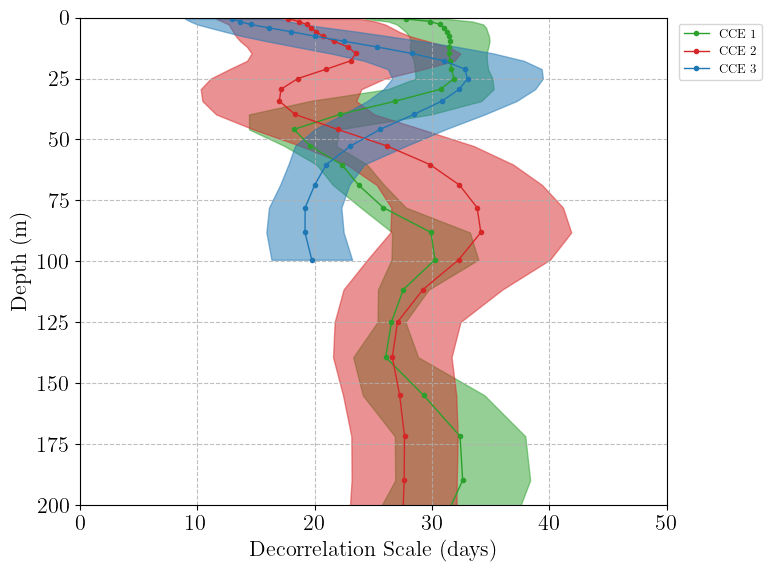

In [8]:
# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the depth-dependent decorrelation time scale
ax.plot(Lt_seg_days[0,:], abs(depth_upper), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(Lt_seg_days[1,:], abs(depth_upper), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(Lt_seg_days[2,:], abs(depth_upper), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth_upper), Lt_seg_days[0,:] - Lt_seg_stdm_days[0,:], Lt_seg_days[0,:] + Lt_seg_stdm_days[0,:], color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth_upper), Lt_seg_days[1,:] - Lt_seg_stdm_days[1,:], Lt_seg_days[1,:] + Lt_seg_stdm_days[1,:], color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth_upper), Lt_seg_days[2,:] - Lt_seg_stdm_days[2,:], Lt_seg_days[2,:] + Lt_seg_stdm_days[2,:], color='tab:blue', alpha=0.5)

# Set figure attributes
ax.set_xlabel(r'Decorrelation Scale (days)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,50)
ax.set_ylim(0,200)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot the total and anomaly variance profile

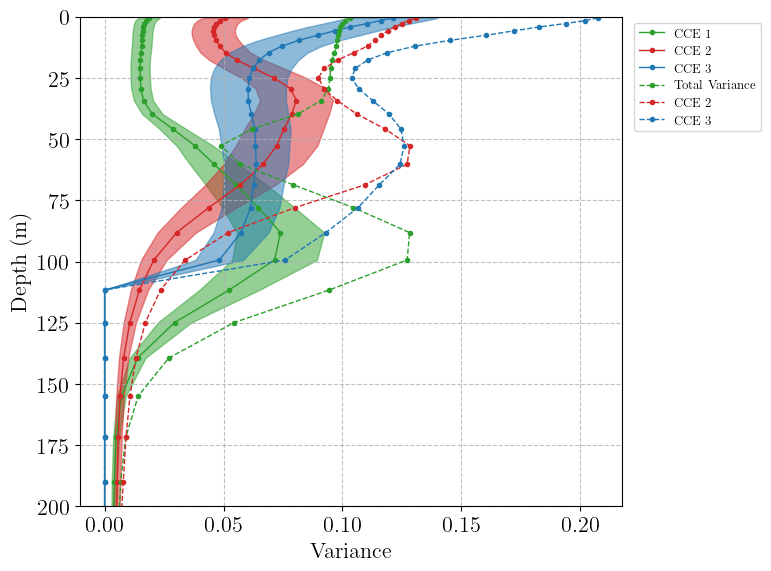

In [9]:
# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the anomaly variance profile
ax.plot(var_anomaly[0,:], abs(depth_upper), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(var_anomaly[1,:], abs(depth_upper), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(var_anomaly[2,:], abs(depth_upper), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Plot the total variance profile
ax.plot(var_total[0,:], abs(depth_upper), '.--', color='tab:green', linewidth=1,label='Total Variance')
ax.plot(var_total[1,:], abs(depth_upper), '.--', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(var_total[2,:], abs(depth_upper), '.--', color='tab:blue', linewidth=1, label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth_upper), var_anomaly[0,:] - var_anomaly_unc[0,:], var_anomaly[0,:] + var_anomaly_unc[0,:], color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth_upper), var_anomaly[1,:] - var_anomaly_unc[1,:], var_anomaly[1,:] + var_anomaly_unc[1,:], color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth_upper), var_anomaly[2,:] - var_anomaly_unc[2,:], var_anomaly[2,:] + var_anomaly_unc[2,:], color='tab:blue', alpha=0.5)

# Set figure attributes
ax.set_xlabel(r'Variance')
ax.set_ylabel('Depth (m)')
#ax.set_xlim(0,50)
ax.set_ylim(0,200)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot fraction of variance explained

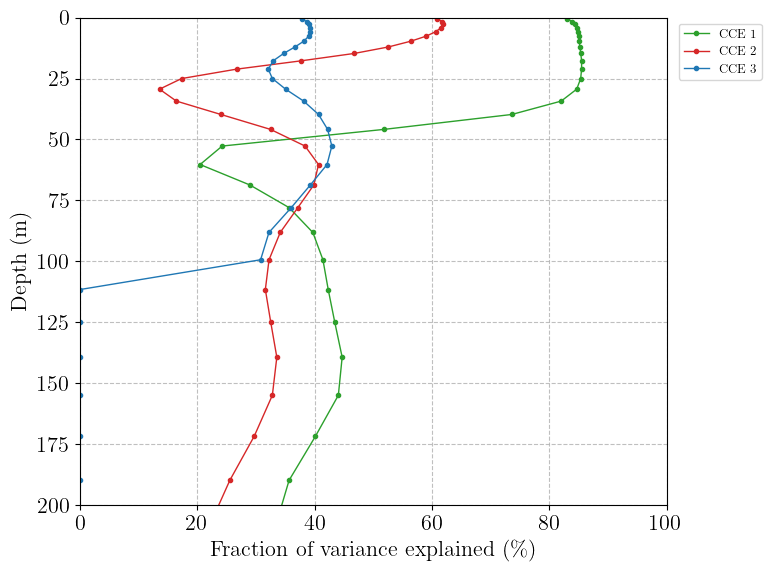

In [10]:
# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the depth-dependent fraction of variance explained 
ax.plot(fve_seg[0,:]*100, abs(depth_upper), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(fve_seg[1,:]*100, abs(depth_upper), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(fve_seg[2,:]*100, abs(depth_upper), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Set figure attributes
ax.set_xlabel(r'Fraction of variance explained (\%)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,100)
ax.set_ylim(0,200)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot spectral slope

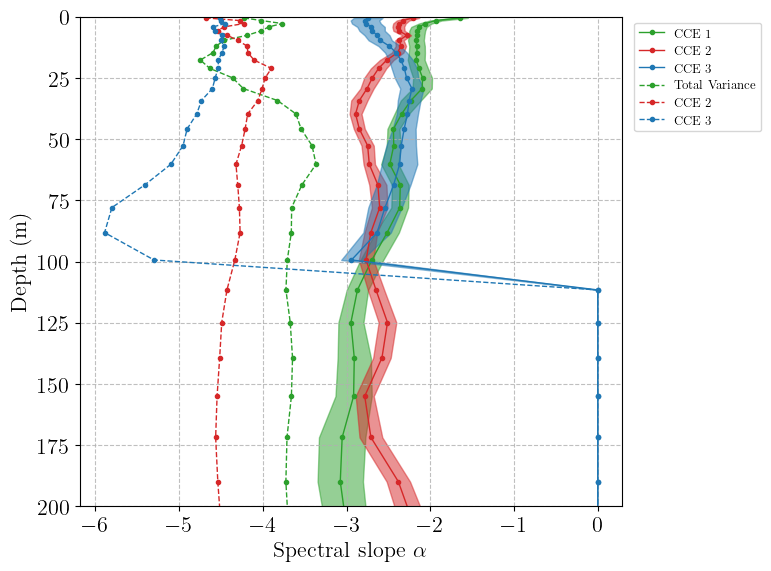

In [11]:
# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the anomaly variance profile
ax.plot(S_seg_slope_sub[0,:], abs(depth_upper), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(S_seg_slope_sub[1,:], abs(depth_upper), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(S_seg_slope_sub[2,:], abs(depth_upper), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Plot the total variance profile
ax.plot(S_seg_slope_sup[0,:], abs(depth_upper), '.--', color='tab:green', linewidth=1,label='Total Variance')
ax.plot(S_seg_slope_sup[1,:], abs(depth_upper), '.--', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(S_seg_slope_sup[2,:], abs(depth_upper), '.--', color='tab:blue', linewidth=1, label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth_upper), S_seg_slope_sub[0,:] - S_seg_slope_sub_unc[0,:], S_seg_slope_sub[0,:] + S_seg_slope_sub_unc[0,:], color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth_upper), S_seg_slope_sub[1,:] - S_seg_slope_sub_unc[1,:], S_seg_slope_sub[1,:] + S_seg_slope_sub_unc[1,:], color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth_upper), S_seg_slope_sub[2,:] - S_seg_slope_sub_unc[2,:], S_seg_slope_sub[2,:] + S_seg_slope_sub_unc[2,:], color='tab:blue', alpha=0.5)

# Set figure attributes
ax.set_xlabel(r'Spectral slope $\alpha$')
ax.set_ylabel('Depth (m)')
#ax.set_xlim(0,50)
ax.set_ylim(0,200)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

In [18]:
print(depth_upper[2:12])
print(S_seg_slope_sub[0,2:12])
print(np.mean(S_seg_slope_sub[0,2:12]))  
print(S_seg_slope_sub_unc[0,2:12])
print((1/10)*np.sqrt(np.sum(S_seg_slope_sub_unc[0,2:12]**2)))

[ -2.79   -4.185  -5.78   -7.595  -9.66  -12.01  -14.68  -17.705 -21.125
 -24.99 ]
[-2.05918881 -2.13554486 -2.1564604  -2.16091824 -2.17167299 -2.15839258
 -2.16012601 -2.16824895 -2.13537492 -2.0920064 ]
-2.13979341574768
[0.07562972 0.0918512  0.09469561 0.0908779  0.09430671 0.09258676
 0.09594122 0.10095455 0.10721095 0.11275101]
0.030405941654137826


Plot the mean spectrum as a function depth for the CCE1 mooring

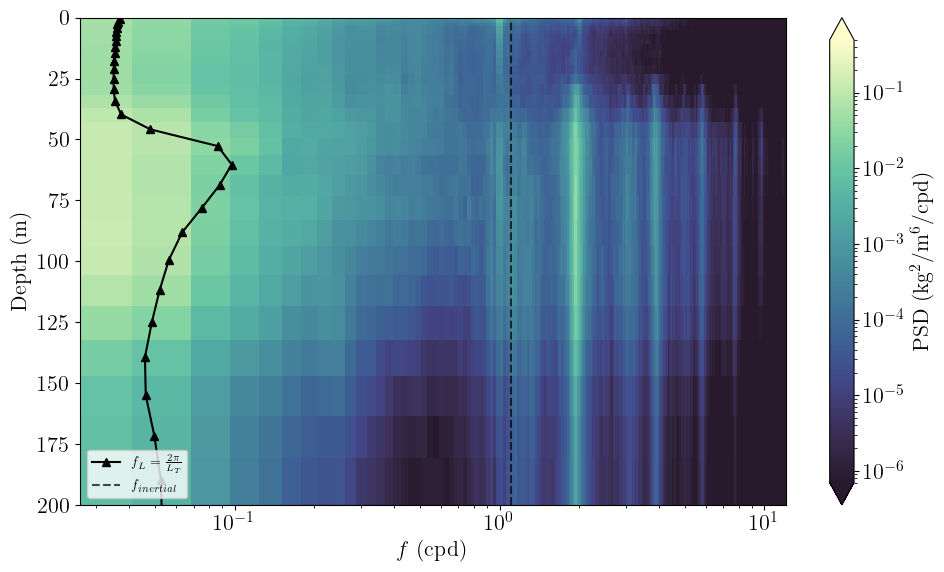

In [58]:
# Multiply the decorrelation scale by pi so that it is comparable to the period of a signal
T_decor = Lt1_days_m/np.pi

# Compute its associated frequency in units of cpd and multiply by 
f_decor = (1/T_decor)

# Compute the interial period in units of cpd
omega = (7.2921*10**(-5))/(2*np.pi)                   # Units: Hz 
f_inertial = 2*omega*np.sin(np.deg2rad(lat[0]))*(86400)  # Units: cpd

# Convert depth to positive
depth_pos = abs(depth)

# Set the fontsize
plt.rcParams.update({'font.size': fontsize})

# Set colormap and levels
cmap = cmo.deep_r
levels=np.arange(-2,6+0.05,0.05)

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=5e-1)

# Create the figure
fig = plt.figure(figsize=(10, 6))

#--- Subplot #1 ---# 
ax1 = fig.add_subplot(111)

# Create meshgrid and zeros surface 
F, D = np.meshgrid(f_cpd_seg, abs(depth_upper))  

# Plot autocorrelation surface
contour = ax1.pcolormesh(F,D,S_seg[0,:,:],cmap=cmap,shading='auto',norm=norm)

# Overlay decorrelation frequency markers
ax1.plot(f_decor, depth_pos, 'k^-', markersize=6, label=r'$f_L = \frac{2\pi}{L_T}$')

# Plot the inertial frequency lines and text
ax1.axvline(f_inertial, color='k', linestyle='--', alpha=0.7, label=r'$f_{inertial}$')

# Set figure attributes
ax1.set_xlabel(r'$f$ (cpd)')
ax1.set_ylabel('Depth (m)')
ax1.set_xscale('log')
ax1.set_ylim(0,200)
ax1.legend(loc='lower left',fontsize=10)

# Set color bar
cbar = fig.colorbar(contour,extend='both')
cbar.set_label(r'PSD (kg$^2$/m$^6$/cpd)')

# Reverse the direction of the x-axis 
ax1.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

In [51]:
# Convert PSD from per Hz → per cpd
S_seg /= (60 * 60 * 24)

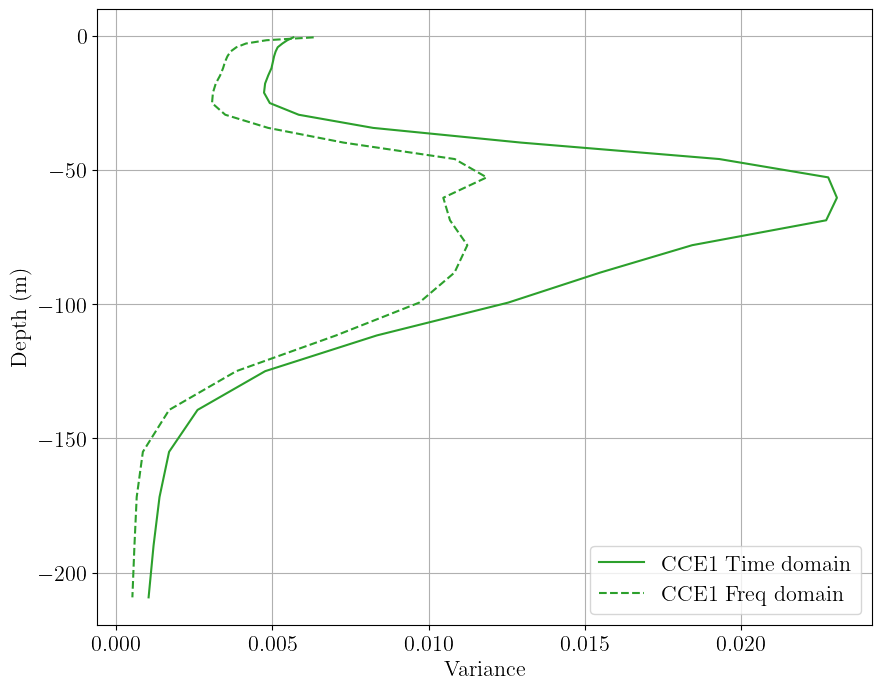

In [43]:
fig, ax = plt.subplots(figsize=(10,8))

ax.plot(var_con[0,:,0], depth_upper, ls='-', color= 'tab:green', label='CCE1 Time domain')
# ax.plot(var_con[1,:,0], depth_upper, ls='-', color= 'tab:red', label='CCE2 Time domain')
# ax.plot(var_con[2,:,0], depth_upper, ls='-', color= 'tab:blue', label='CCE3 Time domain')

ax.plot(var_con[0,:,1], depth_upper, ls='--', color= 'tab:green', label='CCE1 Freq domain')
# ax.plot(var_con[1,:,1], depth_upper, ls='--', color= 'tab:red', label='CCE2 Freq domain')
# ax.plot(var_con[2,:,1], depth_upper, ls='--', color= 'tab:blue', label='CCE3 Freq domain')

ax.set_xlabel('Variance')
ax.set_ylabel('Depth (m)')
ax.grid('on')
ax.legend(loc='lower right')

Compute the monthly climatology decorrelation scale

In [33]:
# Initialize arrays 
mean_autocorr = {
    isite: {idepth: {} for idepth in range(Ndepth)}
    for isite in range(Nsite)
}
Lt_clima = np.zeros((Nsite,Ndepth,12))

# Loop through mooring site and depth 
for isite in range(Nsite):
    for idepth in range(Ndepth):

        # Grab the autocorrelation functions at the ith depth and jth site
        acf_dict     = autocorr_monthly[isite][idepth]
        timelag_dict = timelag_monthly[isite][idepth]

        # check if the dictionare is empty
        if len(acf_dict) == 0:
            continue

        # Infer number of lags from the first entry
        example_acf = next(iter(acf_dict.values()))
        n_lag = len(example_acf)

        # Loop through months
        for month in range(1, 13):

            # Collect all autocorrelation functions corresponding to this month across years
            acf_list = [
                acf for (year_m, month_m), acf in acf_dict.items()
                if month_m == month
            ]
            timelag_list = [
                timelag for (year_m, month_m), timelag in timelag_dict.items()
                if month_m == month
            ]

            # Check if there is no data for this month at this site/depth
            if len(acf_list) == 0:
                continue

            # Find the minimum length across years for this month
            min_len = min(a.shape[0] for a in acf_list)

            # Truncate all ACFs to this common length
            acf_trimmed = [a[:min_len] for a in acf_list]
            timelag_trimmed = [tl[:min_len] for tl in timelag_list]

            # Stack into array: shape (n_years, n_lag)
            autocorr_stack = np.stack(acf_trimmed, axis=0)
            timelag_stack = np.stack(timelag_trimmed, axis=0)

            # Compute average across years
            autocorr_mean = np.mean(autocorr_stack, axis=0)
            timelag_m     = np.mean(timelag_stack, axis=0)

            # Compute decorrelation scale
            Lt_clima[isite,idepth,(month-1)]  = compute_decor_scale_optimize(autocorr_mean,timelag_m,T,'unbiased',0)

# Convert decorrelation scales into days
Lt_clima_days = Lt_clima * (1/60) * (1/60) * (1/24)

Compute the climatological profiles and the mean climatological profile

In [34]:
# Set parameters
n_site, n_time, n_depth = data.shape

# Extract month index from time variable
months = (time.astype("datetime64[M]").astype(int) % 12) + 1
years  = time.astype("datetime64[Y]").astype(int) + 1970               # actual calendar year

# Set the unique years and the number of years
unique_years, year_idx = np.unique(years, return_inverse=True)
n_year = unique_years.size

# ------------------------------------------------------------------
# Compute per-year, per-month means/variances
# ------------------------------------------------------------------

# Preallocate array 
month_mean_year = np.full((n_site, n_year, 12, n_depth), np.nan, float)
month_var_year  = np.full((n_site, n_year, 12, n_depth), np.nan, float)
stdm_month_mean_year  = np.full((n_site, n_year, 12, n_depth), np.nan, float)
stdm_month_var_year   = np.full((n_site, n_year, 12, n_depth), np.nan, float)

# Loop through months
for m in range(1, 13):

    # Index for month dimension (0..11)
    mi = m - 1

    # Obtain the decorrelation-based "samples per decorrelation time" for the ith month
    n_d = Lt_clima_days[:, :, mi] / T_days 

    # Loop through years
    for iy in range(n_year):

        # Select time indices belonging to this (month, year)
        mask = (months == m) & (year_idx == iy)
        if not np.any(mask):
            continue

        # Obtain data for this site × (month,year) × depth: shape (n_site, n_time_m, n_depth)
        data_tmp = data[:, mask, :]

        # Compute per-year monthly mean and variance over time axis
        month_mean_year[:, iy, mi, :] = np.nanmean(data_tmp, axis=1)
        month_var_year[:,  iy, mi, :] = np.nanvar(data_tmp, axis=1, ddof=1)

        # Count valid samples to get effective N
        valid    = np.isfinite(data_tmp)
        count_m = np.sum(valid, axis=1)                # (n_site, n_depth)

        # Compute effective degrees of freedom
        Neff = count_m / n_d                        # (n_site, n_depth)

        # Compute the standard error of per-year monthly mean and variance
        var_tmp = month_var_year[:,  iy, mi, :]
        std_tmp = np.sqrt(var_tmp)
        stdm_month_mean_year[:, iy, mi, :] = std_tmp / np.sqrt(Neff) 
        stdm_month_var_year[:,  iy, mi, :] = var_tmp * np.sqrt(2.0 / (Neff - 1))


# ---------------------------------------------------------------------
# Climatological monthly mean & mean variance across years
# ---------------------------------------------------------------------
# Mean over years (axis=1) → (n_site, 12, n_depth)
data_clim_m   = np.nanmean(month_mean_year, axis=1)    # climatological monthly mean
data_clim_var = np.nanmean(month_var_year,  axis=1)    # mean within-month variance across years

# Typical within-month std dev (square root of mean variance)
data_clim_std_within = np.sqrt(data_clim_var)          # (n_site, 12, n_depth)

# ---------------------------------------------------------------------
# Propagate error to get SE of climatological monthly mean & mean variance
#   Includes:
#   - interannual scatter of monthly means/variances
#   - sampling Standard error of each per-year monthly estimate
# ---------------------------------------------------------------------

# Number of years contributing for each (site, month, depth)
Nyears = np.sum(np.isfinite(month_mean_year), axis=1)   # (n_site, 12, n_depth)
Nyears = np.where(Nyears > 0, Nyears, np.nan)

# ---- For the climatological monthly mean ---- #

# Interannual spread of monthly means (between-year variability)
std_over_years = np.nanstd(month_mean_year, axis=1, ddof=1)      # (n_site, 12, n_depth)

# Component 1: between-year contribution
var_between_mean = std_over_years**2 / Nyears

# Component 2: sampling contribution from per-year SEs
sum_se2_mean = np.nansum(stdm_month_mean_year**2, axis=1)          # sum over years
var_sampling_mean = sum_se2_mean / (Nyears**2)

# Total SE of climatological monthly mean
data_clim_stdm = np.sqrt(var_between_mean + var_sampling_mean)   # (n_site, 12, n_depth)

# ---- For the mean variance across years ---- #

# Interannual spread of monthly variances
std_var_over_years = np.nanstd(month_var_year, axis=1, ddof=1)

# Between-year contribution
var_between_var = std_var_over_years**2 / Nyears

# Sampling contribution from SE(var_{m,y})
sum_se2_var = np.nansum(stdm_month_var_year**2, axis=1)
var_sampling_var = sum_se2_var / (Nyears**2)

# Total SE of the mean variance across years
data_clim_stdv = np.sqrt(var_between_var + var_sampling_var)     # (n_site, 12, n_depth)

# ---------------------------------------------------------------------
# Annual-mean profile & its standard error (averaging over the 12 months)
# ---------------------------------------------------------------------
# Annual-mean climatology (averaging over months)
data_clim_mp = np.nanmean(data_clim_m,   axis=1)  # (n_site, n_depth)
data_clim_vp = np.nanmean(data_clim_var, axis=1)

# Number of months contributing
Nmonths = np.sum(np.isfinite(data_clim_m), axis=1)
Nmonths = np.where(Nmonths > 0, Nmonths, np.nan)

# Propagate monthly SEs into annual-mean SE
data_clim_stdmp = np.sqrt(np.nansum(data_clim_stdm**2, axis=1)) / Nmonths
data_clim_stdvp = np.sqrt(np.nansum(data_clim_stdv**2, axis=1)) / Nmonths


/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/1987538751.py:64: RuntimeWarning: Mean of empty slice
  data_clim_m   = np.nanmean(month_mean_year, axis=1)    # climatological monthly mean
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/1987538751.py:65: RuntimeWarning: Mean of empty slice
  data_clim_var = np.nanmean(month_var_year,  axis=1)    # mean within-month variance across years
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/1987538751.py:115: RuntimeWarning: Mean of empty slice
  data_clim_mp = np.nanmean(data_clim_m,   axis=1)  # (n_site, n_depth)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_3490/1987538751.py:116: RuntimeWarning: Mean of empty slice
  data_clim_vp = np.nanmean(data_clim_var

Plot the mean climatological profile 

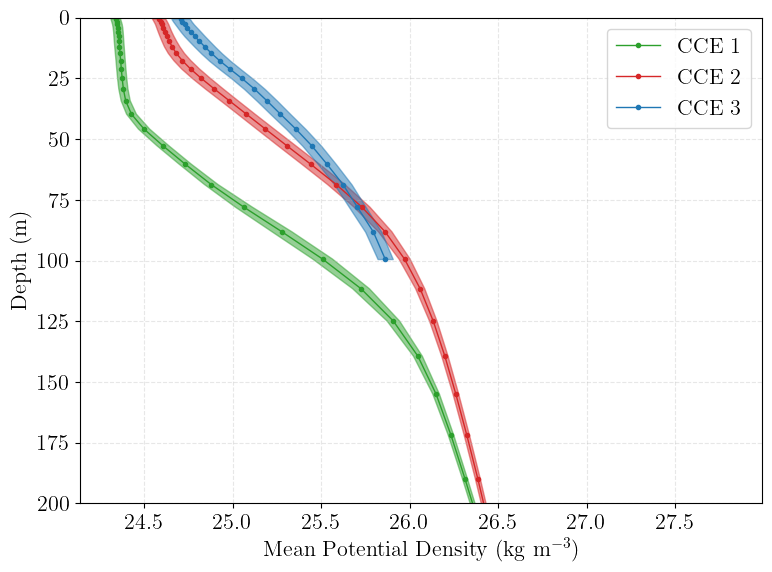

In [35]:
# Create the figure
fig,ax = plt.subplots(figsize=(8,6))

# Plot the mean climatological profile
ax.plot(data_clim_mp[0,:], abs(depth), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(data_clim_mp[1,:], abs(depth), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(data_clim_mp[2,:], abs(depth), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth), data_clim_mp[0,:] - data_clim_stdmp[0,:], data_clim_mp[0,:] + data_clim_stdmp[0,:], color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth), data_clim_mp[1,:] - data_clim_stdmp[1,:], data_clim_mp[1,:] + data_clim_stdmp[1,:], color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth), data_clim_mp[2,:] - data_clim_stdmp[2,:], data_clim_mp[2,:] + data_clim_stdmp[2,:], color='tab:blue', alpha=0.5)

# Loop through months
# for imonth in range(12): 

    # Plot the monthly mean climatology 
    # ax.plot(data_clim_m[0,imonth,:], abs(depth), '--', color='tab:green', linewidth=1, alpha=0.3)
    # ax.plot(data_clim_m[1,imonth,:], abs(depth), '--', color='tab:red', linewidth=1, alpha=0.3)
    # ax.plot(data_clim_m[2,imonth,:], abs(depth), '--', color='tab:blue', linewidth=1, alpha=0.3)

    # Plot standard error of the mean profiles for each mooring
    # ax.fill_betweenx(abs(depth), data_clim_m[0,imonth,:] - data_clim_stdm[0,imonth,:], data_clim_m[0,imonth,:] + data_clim_stdm[0,imonth,:], color='tab:green', alpha=0.3)
    # ax.fill_betweenx(abs(depth), data_clim_m[1,imonth,:] - data_clim_stdm[1,imonth,:], data_clim_m[1,imonth,:] + data_clim_stdm[1,imonth,:], color='tab:red', alpha=0.5)
    # ax.fill_betweenx(abs(depth), data_clim_m[2,imonth,:] - data_clim_stdm[2,imonth,:], data_clim_m[2,imonth,:] + data_clim_stdm[2,imonth,:], color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_xlabel('Mean ' + label)
ax.set_ylabel("Depth (m)")
ax.set_ylim([0,200])
ax.invert_yaxis()
ax.legend()
ax.grid(True,linestyle='--',alpha=0.3)

# Show figure
plt.tight_layout()
plt.show()

Plot the mean variance climatological profile

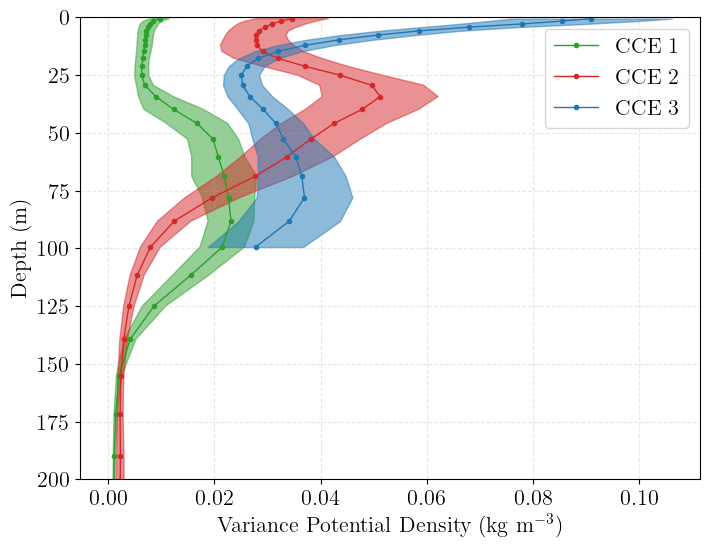

In [36]:
# Create the figure
fig,ax = plt.subplots(figsize=(8,6))

# Plot the mean variance climatological profile
ax.plot(data_clim_vp[0,:], abs(depth), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(data_clim_vp[1,:], abs(depth), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(data_clim_vp[2,:], abs(depth), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Plot standard error of the mean variance profiles for each mooring
ax.fill_betweenx(abs(depth), data_clim_vp[0,:] - data_clim_stdvp[0,:], data_clim_vp[0,:] + data_clim_stdvp[0,:], color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth), data_clim_vp[1,:] - data_clim_stdvp[1,:], data_clim_vp[1,:] + data_clim_stdvp[1,:], color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth), data_clim_vp[2,:] - data_clim_stdvp[2,:], data_clim_vp[2,:] + data_clim_stdvp[2,:], color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_xlabel('Variance ' + label)
ax.set_ylabel("Depth (m)")
ax.set_ylim([0,200])
ax.invert_yaxis()
ax.legend()
ax.grid(True,linestyle='--',alpha=0.3)

## Section 6: Compute the scale decomposition of the decorrelation scale

Load in the data for the decorrelation scale as a function of scale for set spectral slopes

In [37]:
#-------------------------------------------------------#
# Simulated Data
#-------------------------------------------------------#
PATH_sim = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
ROOT_sim = "/data/synthetic"
filename_sim    = PATH_sim + ROOT_sim + "/decorrelation_window_size_fit.npz"

# Load data 
ds_sim   = np.load(filename_sim, allow_pickle=True)

# Extract data variables
Lt_av          = ds_sim['Lt_av']    # Units: days
Lt_stdm        = ds_sim['Lt_stdm']  # Units: days
Lt_fit         = ds_sim['Lt_fit']   # Units: days         
scales         = ds_sim['scales']   # Units: months
alphas          = ds_sim['alpha']

For a single depth, look at the scale decomposition of the decorrelation scale

In [38]:
# Set window sizes (units: number of samples)
n_hours      = np.shape(data)[1]
min_window   = 100       
max_window   = n_hours // 2     # at least 3 windows fit
n_windows    = 50
wins         = np.linspace(min_window, max_window, n_windows)
window_sizes = np.round(wins).astype(int)

# Set parameters
w1, w2 = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Specifies the radian Frequency for annual and semi-annual cycles. Units: rad/sec
depth_level = -10                                            # Specifies the depth analyzed. Units: meters
overlap   = 0.5                                              # Specifies the fractional overlap between segments (e.g., 0.75 for 75% overlap)

# Find depth level 
idx_depth = np.argmin(abs(depth - depth_level))

# Extract a depth at each CCE site
data_cce1 = data[0, :, idx_depth]
data_cce2 = data[1, :, idx_depth]
data_cce3 = data[2, :, idx_depth]

# Compute the elapsed time from beginning of segmented time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

if option_var in ('temp', 'sal', 'density'):

    # Remove the annual and semi-annual cycles
    hfit_cce1, *_ = unweighted_lsf(data_cce1, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
    hfit_cce2, *_ = unweighted_lsf(data_cce2, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
    hfit_cce3, *_ = unweighted_lsf(data_cce3, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
    data_cce1_rm = data_cce1 - hfit_cce1
    data_cce2_rm = data_cce2 - hfit_cce2
    data_cce3_rm = data_cce3 - hfit_cce3

else: 

    # Do NOT remove the annual and semi-annual cycles
    data_cce1_rm = data_cce1 
    data_cce2_rm = data_cce2 
    data_cce3_rm = data_cce3


# Preform scale analysis
scales_cce1, Lt_cce1_av, Lt_cce1_stdm, window_cce1_dict = windowed_decorrelation_scale(data_cce1_rm, time_elapsed, T, 
                                                                         scales=window_sizes, norm=False, overlap=overlap, 
                                                                         return_windows=True)
scales_cce2, Lt_cce2_av, Lt_cce2_stdm, window_cce2_dict = windowed_decorrelation_scale(data_cce2_rm, time_elapsed, T, 
                                                                         scales=window_sizes, norm=False, overlap=overlap, 
                                                                         return_windows=True)
scales_cce3, Lt_cce3_av, Lt_cce3_stdm, window_cce3_dict = windowed_decorrelation_scale(data_cce3_rm, time_elapsed, T, 
                                                                         scales=window_sizes, norm=False, overlap=overlap, 
                                                                         return_windows=True)

# Convert window size to units of days
if option_bin == 0:
    window_sizes_days = window_sizes / 24 
else: 
    window_sizes_days = window_sizes / 2

# Convert decorrelation scales to units of days
Lt_cce1_av_days = Lt_cce1_av * (1/60) * (1/60) * (1/24)
Lt_cce2_av_days = Lt_cce2_av * (1/60) * (1/60) * (1/24)
Lt_cce3_av_days = Lt_cce3_av * (1/60) * (1/60) * (1/24)

Lt_cce1_stdm_days = Lt_cce1_stdm * (1/60) * (1/60) * (1/24)
Lt_cce2_stdm_days = Lt_cce2_stdm * (1/60) * (1/60) * (1/24)
Lt_cce3_stdm_days = Lt_cce3_stdm * (1/60) * (1/60) * (1/24)

Plot the decorrelation scale as a function of window-size (i.e., scale)

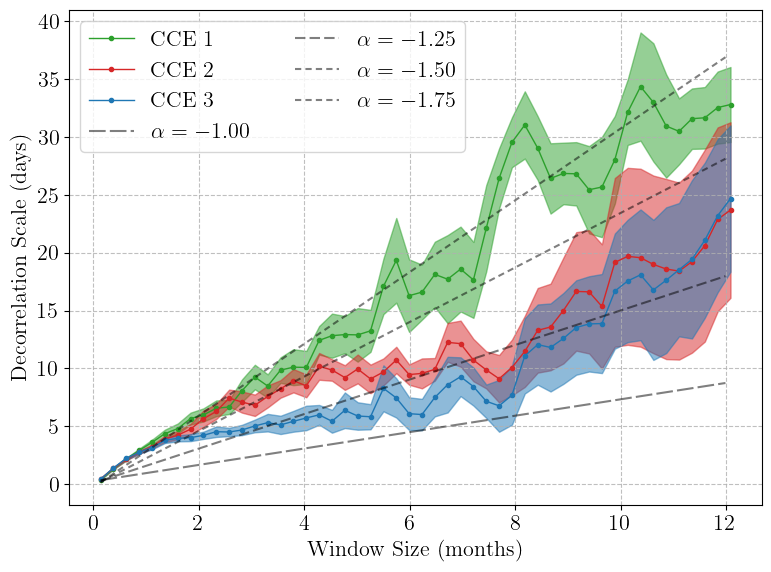

In [39]:
# Set plotting parameters
window_size_months = window_sizes_days / 30.44  # convert days to months
colors = cmo.deep_r(np.linspace(0, 1, len(alphas)))  # color map for multiple slopes

# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the depth-dependent decorrelation time scale
ax.plot(window_size_months, Lt_cce1_av_days, '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(window_size_months, Lt_cce2_av_days, '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(window_size_months, Lt_cce3_av_days, '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_between(window_size_months, Lt_cce1_av_days - Lt_cce1_stdm_days, Lt_cce1_av_days + Lt_cce1_stdm_days, color='tab:green', alpha=0.5)
ax.fill_between(window_size_months, Lt_cce2_av_days - Lt_cce2_stdm_days, Lt_cce2_av_days + Lt_cce2_stdm_days, color='tab:red', alpha=0.5)
ax.fill_between(window_size_months, Lt_cce3_av_days - Lt_cce3_stdm_days, Lt_cce3_av_days + Lt_cce3_stdm_days, color='tab:blue', alpha=0.5)

# Plot the linear fit to the decorrelation scale vs. window size relation
ax.plot(scales, Lt_fit[0, :], linestyle=(0, (8, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alphas[0]))
ax.plot(scales, Lt_fit[1, :], linestyle=(0, (5, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alphas[1]))
ax.plot(scales, Lt_fit[2, :], linestyle=(0, (3, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alphas[2]))
ax.plot(scales, Lt_fit[3, :], linestyle=(0, (3, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alphas[3]))

# Set figure attributes
ax.set_xlabel('Window Size (months)')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(ncol=2,loc='upper left', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

## Section 7: Save the data in a .npz file

In [40]:
# Check if file exists, then delete it
if (option_var == 'u_along') & (option_bin == 1):
    file_path = PATH + "mitgcm_" + option_var + "_temporal_scale_data_bin.npz"
elif (option_var == 'v_cross') & (option_bin == 1):
    file_path = PATH + "mitgcm_" + option_var + "_temporal_scale_data_bin.npz"
else: 
    file_path = PATH + "mitgcm_" + option_var + "_temporal_scale_data.npz"
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Temporal decorrelation scale analysis of MITgcm ' + option_var + ' profile time series at the three CCE mooring locations. Here, the annual and semi-annual cycles are removed before computing the decorrelation scale.',
    'source': 'MITgcm model output',
    'coordinates units': '1 hr'
}

# Save data arrays and metadata to a .npz file
np.savez(file_path, 
        autocorr1         = autocorr1,
        autocorr2         = autocorr2,
        autocorr3         = autocorr3,
        time_scale1       = time_scale1,          # Units: seconds
        time_scale2       = time_scale2,          # Units: seconds
        time_scale3       = time_scale3,          # Units: seconds
        Lt1               = Lt1_days_m,           # Units: days
        Lt2               = Lt2_days_m,           # Units: days
        Lt3               = Lt3_days_m,           # Units: days
        Lt1_seg           = Lt_seg_days[0,:],     # Units: days
        Lt2_seg           = Lt_seg_days[1,:],     # Units: days
        Lt3_seg           = Lt_seg_days[2,:],     # Units: days
        Lt1_seg_stdm      = Lt_seg_stdm_days[0,:],# Units: days
        Lt2_seg_stdm      = Lt_seg_stdm_days[1,:],# Units: days
        Lt3_seg_stdm      = Lt_seg_stdm_days[2,:],# Units: days
        Lt1_scale         = Lt_cce1_av_days,      # Units: days
        Lt2_scale         = Lt_cce2_av_days,        # Units: days
        Lt3_scale         = Lt_cce3_av_days,        # Units: days
        Lt1_scale_stdm    = Lt_cce1_stdm_days,      # Units: days
        Lt2_scale_stdm    = Lt_cce2_stdm_days,      # Units: days
        Lt3_scale_stdm    = Lt_cce3_stdm_days,      # Units: days
        meanPeriod1_m     = meanPeriod1_m,        # Units: days
        meanPeriod2_m     = meanPeriod2_m,        # Units: days
        meanPeriod3_m     = meanPeriod3_m,        # Units: days
        S1                = S1,              
        S2                = S2,              
        S3                = S3,      
        S_seg             = S_seg,
        CI_seg            = CI_seg,    
        CI1               = CI1, 
        CI2               = CI2, 
        CI3               = CI3, 
        f_cpd             = f_cpd,           # Units: days
        f_cpd_seg         = f_cpd_seg,       # Units: cpd 
        V1                = V1,              # Units: units^2
        V2                = V2, 
        V3                = V3,
        p1                = p1,              # Units: unitless
        p2                = p2, 
        p3                = p3,
        L1                = L1,              # Units: Days
        L2                = L2, 
        L3                = L3,
        fve_seg           = fve_seg,
        var_tot_prof      = var_total, 
        var_anom_prof     = var_anomaly, 
        var_tot_unc_prof  = var_total_unc, 
        var_anom_unc_prof = var_anomaly_unc,
        S_seg_slope_sub   = S_seg_slope_sub, 
        S_seg_slope_sup   = S_seg_slope_sup, 
        S_seg_slope_sub_unc = S_seg_slope_sub_unc,
        S_seg_slope_sup_unc = S_seg_slope_sup_unc, 
        mean_profile      = mean_profile, 
        var_profile       = var_profile,
        stdv1_profile     = stdv1_profile, 
        stdv2_profile     = stdv2_profile, 
        stdv3_profile     = stdv3_profile,  
        stdm1_profile     = stdm1_profile, 
        stdm2_profile     = stdm2_profile, 
        stdm3_profile     = stdm3_profile,  
        mean_clim_m       = data_clim_mp, 
        stdm_clim_m       = data_clim_stdmp,
        mean_clim         = data_clim_m,  
        stdm_clim         = data_clim_stdm,
        var_clim_m        = data_clim_vp, 
        stdv_clim_m       = data_clim_stdvp,
        var_clim          = data_clim_var, 
        stdv_clim         = data_clim_stdv,     
        lon               = lon,
        lat               = lat,
        depth             = depth,
        scale             = window_size_months,        # Units: months
        metadata          = metadata
        )

Save the mixed layer depth data 

In [41]:
# Check if file exists, then delete it
file_mld_path = PATH + "mitgcm_cce_mld_climatology.npz"
if os.path.exists(file_mld_path):
    os.remove(file_mld_path)

# Set metadata
metadata = {
    'description': 'Mixed layer time series at the three CCE mooring locations. The mixed layer is computed using the potential energy method.',
    'source': 'MITgcm model output',
    'coordinates units': '1 hr'
}

if option_var == 'density': 
    
    # Save data arrays and metadata to a .npz file
    np.savez(file_mld_path,
        mld               = mld_PE, 
        mld_monthly_mean  = mld_monthly_mean, 
        mld_monthly_var   = mld_monthly_var, 
        mld_monthly_stdm  = mld_monthly_stdm, 
        mld_monthly_stdv  = mld_monthly_stdv, 
        lon               = lon,
        lat               = lat,
        time              = time_dt,
        time_monthly      = monthly_time,        # Units: months
        metadata          = metadata
        )

## Developmental Code

**Method 2**: Compute the decorrelation scale with the bootstrap method

In [42]:
# # Set parameters for bootstrap method
# window_length = int(365*(24/1))                 # Number of points in a window (0.5 year)
# stride = int((183*(24/1))/24)                   # Number of points for stride length between windows (1 year) 
# J      = ((Ntime - window_length)/stride) + 1   # Number of windows 
# m      = int(J**(1/2))                          # Number of windows per bootstrap iteration 
# B      = 1000                                   # Number of bootstrap replicates

# # Initialize arrays
# Lt_boot = np.zeros((Nsite,Ndepth_upper))
# Lt_boot_std = np.zeros((Nsite,Ndepth_upper))
# Lt_boot_stdm = np.zeros((Nsite,Ndepth_upper))
# Lt_boot_ci = np.zeros((2,Nsite,Ndepth_upper))

# # Loop over each site
# for isite in range(Nsite):

#     # Print site progress
#     print(f"\nProcessing site {isite+1} of {Nsite}")
    
#     # Loop over each depth
#     for idepth in range(Ndepth_upper):

#         # Set progress bar
#         progress = (idepth) / (Ndepth_upper)
#         sys.stdout.write(f"\rProgress: {progress:.1%}")
#         sys.stdout.flush()
        
#         # Extract full time series at this site and depth
#         var_series = data[isite, :, idepth]

#         # Skip depth if all values are masked
#         if np.all(var_series.mask):
#             continue

#         # Remove seasonal cycle
#         hfit_var, *_ = unweighted_lsf(var_series, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
#         var_rm = var_series - hfit_var

#         # Compute decorrelation scale estimate and uncertainty
#         Lt_boot[isite,idepth], Lt_boot_std[isite,idepth], Lt_boot_stdm[isite,idepth], Lt_boot_ci[:,isite,idepth], _ = bootstrap_decorrelation_scale(var_rm, time_elapsed, window_length, T, 
#                                                                                                                                                    bias='unbiased', norm=0, stride=stride, 
#                                                                                                                                                    m=m, B=B, lag=None, random_seed=42)
        
# # Convert to days
# Lt_boot_days      = Lt_boot*(1/60)*(1/60)*(1/24)
# Lt_boot_std_days  = Lt_boot_std*(1/60)*(1/60)*(1/24)
# Lt_boot_stdm_days  = Lt_boot_stdm*(1/60)*(1/60)*(1/24)

# # Mask zero values 
# Lt_boot_days = np.ma.masked_equal(Lt_boot_days, 0)
# Lt_boot_std_days = np.ma.masked_equal(Lt_boot_std_days, 0)
# Lt_boot_stdm_days = np.ma.masked_equal(Lt_boot_stdm_days, 0)

Plot the decorrelation scale with bootstrap uncertainty

In [43]:
# # Create the figure
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)

# # Plot the depth-dependent decorrelation time scale
# ax.plot(Lt_boot_days[0,:], abs(depth), '.-', color='tab:green', linewidth=1,label='CCE 1')
# ax.plot(Lt_boot_days[1,:], abs(depth), '.-', color='tab:red', linewidth=1, label='CCE 2')
# ax.plot(Lt_boot_days[2,:], abs(depth), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# # Plot standard error of the mean profiles for each mooring
# ax.fill_betweenx(abs(depth), Lt_boot_days[0,:] - Lt_boot_std_days[0,:], Lt_boot_days[0,:] + Lt_boot_std_days[0,:], color='tab:green', alpha=0.5)
# ax.fill_betweenx(abs(depth), Lt_boot_days[1,:] - Lt_boot_std_days[1,:], Lt_boot_days[1,:] + Lt_boot_std_days[1,:], color='tab:red', alpha=0.5)
# ax.fill_betweenx(abs(depth), Lt_boot_days[2,:] - Lt_boot_std_days[2,:], Lt_boot_days[2,:] + Lt_boot_std_days[2,:], color='tab:blue', alpha=0.5)

# # Set figure attributes
# ax.set_xlabel(r'Decorrelation Scale (days)')
# ax.set_ylabel('Depth (m)')
# ax.set_xlim(0,50)
# ax.set_ylim(0,200)
# ax.grid(True,linestyle='--',alpha=0.8)
# ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# # Reverse the direction of the x-axis 
# ax.invert_yaxis() 

# # Display figure
# plt.tight_layout()
# plt.show()

In [44]:
# # Set parameters
# n_site, n_time, n_depth = data.shape

# # Extract month index from time variable
# months = (time.astype("datetime64[M]").astype(int) % 12) + 1

# # Preallocate output arrays
# data_clim_m     = np.full((n_site, 12, n_depth), np.nan, float)  
# data_clim_stdm  = np.full((n_site, 12, n_depth), np.nan, float)   
# data_clim_var   = np.full((n_site, 12, n_depth), np.nan, float)
# data_clim_stdv  = np.full((n_site, 12, n_depth), np.nan, float)

# # Loop over months 
# for m in range(1, 13):

#     # Select all time indices belonging to this month
#     mask = (months == m)
#     if not np.any(mask):
#         # If no samples in this month, skip
#         continue

#     # Extract data for this month
#     data_tmp = data[:, mask, :]

#     # Count valid samples along time axis
#     valid = np.isfinite(data_tmp)
#     count_m = np.sum(valid, axis=1)             

#     # Compute monthly mean 
#     mean_prof = np.nanmean(data_tmp, axis=1)         

#     # Compute standard deviation and variance (this is combining )
#     std_prof = np.nanstd(data_tmp, axis=1, ddof=1)    
#     var_prof = np.nanvar(data_tmp, axis=1, ddof=1)

#     # Compute the number of degrees of freedom 
#     n_d = Lt_clima_days[:,:,(m-1)]/T_days
#     Neff = count_m/n_d

#     # Compute the standard error of the mean and variance
#     stdm_prof = std_prof/np.sqrt(Neff)
#     stdv_prof = var_prof* np.sqrt(2/(Neff-1))

#     # Save results
#     data_clim_m[:, m-1, :]     = mean_prof
#     data_clim_stdm[:,  m-1, :] = stdm_prof
#     data_clim_var[:, m-1, :]   = var_prof
#     data_clim_stdv[:,  m-1, :] = stdv_prof

# # Compute the mean and standard error of the mean climatology profile
# data_clim_mp = np.nanmean(data_clim_m,axis=1)
# data_clim_vp = np.nanmean(data_clim_var,axis=1)
# data_clim_stdmp = (1/12.0) * np.sqrt(np.nansum(data_clim_stdm**2, axis=1)) #np.nanstd(data_clim_m,axis=1)/np.sqrt(12) 
# data_clim_stdvp = (1/12.0) * np.sqrt(np.nansum(data_clim_stdv**2, axis=1)) #np.nanstd(data_clim_var,axis=1)/np.sqrt(12)

In [45]:
# # Set parameters for scale analysis
# w1, w2 = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Specifies the radian Frequency for annual and semi-annual cycles. Units: rad/sec
# depth_level = -10                                            # Specifies the depth analyzed. Units: meters
# if option_bin == 0:                                          # No binning case 
#     n_hours = np.shape(data)[1]                              # total samples
#     min_window = 100                                         # ~4 days
#     max_window = n_hours // 2                                # at least 3 windows fit with 50% overlap
# else:                                                        # Binning case
#     n_12hours = np.shape(data)[1]                            # total samples
#     min_window = 25                                          # 12.5 days
#     max_window = n_12hours // 2                              # at least 3 windows fit with 50% overlap
# n_windows  = 50
# overlap   = 0.5                                              # Specifies the fractional overlap between segments (e.g., 0.75 for 75% overlap)
# option_log = False                                            # True for logarithmic spacing, False for linear spacing

# # Linearly or logarithmic spaced windows rounded to the nearest integer
# if option_log == False: 
#     wins = np.linspace(min_window, max_window, n_windows)
# else: 
#     wins = np.logspace(np.log10(min_window), np.log10(max_window), n_windows)
# window_sizes = np.round(wins).astype(int)

# # Remove duplicates (because rounding may create them)
# window_sizes = np.unique(window_sizes)

# # Find depth level 
# idx_depth = np.argmin(abs(depth - depth_level))

# # Extract a depth at each CCE site
# data_cce1 = data[0, :, idx_depth]
# data_cce2 = data[1, :, idx_depth]
# data_cce3 = data[2, :, idx_depth]

# # Compute the elapsed time from beginning of segmented time series (units: seconds)
# t0 = time[0]
# time_elapsed = np.array([(t - t0).total_seconds() for t in time])

# if option_var in ('temp', 'sal', 'density'):

#     # Remove the annual and semi-annual cycles
#     hfit_cce1, *_ = unweighted_lsf(data_cce1, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
#     hfit_cce2, *_ = unweighted_lsf(data_cce2, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
#     hfit_cce3, *_ = unweighted_lsf(data_cce3, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
#     data_cce1_rm = data_cce1 - hfit_cce1
#     data_cce2_rm = data_cce2 - hfit_cce2
#     data_cce3_rm = data_cce3 - hfit_cce3

# else: 

#     # Do NOT remove the annual and semi-annual cycles
#     data_cce1_rm = data_cce1 
#     data_cce2_rm = data_cce2 
#     data_cce3_rm = data_cce3


# # Preform scale analysis
# scales_cce1, Lt_cce1_av, Lt_cce1_stdm, window_cce1_dict = windowed_decorrelation_scale(data_cce1_rm, time_elapsed, T, 
#                                                                          scales=window_sizes, norm=False, overlap=overlap, 
#                                                                          return_windows=True)
# scales_cce2, Lt_cce2_av, Lt_cce2_stdm, window_cce2_dict = windowed_decorrelation_scale(data_cce2_rm, time_elapsed, T, 
#                                                                          scales=window_sizes, norm=False, overlap=overlap, 
#                                                                          return_windows=True)
# scales_cce3, Lt_cce3_av, Lt_cce3_stdm, window_cce3_dict = windowed_decorrelation_scale(data_cce3_rm, time_elapsed, T, 
#                                                                          scales=window_sizes, norm=False, overlap=overlap, 
#                                                                          return_windows=True)

# # Convert window size to units of days
# if option_bin == 0:
#     window_sizes_days = window_sizes / 24 
# else: 
#     window_sizes_days = window_sizes / 2

# # Convert decorrelation scales to units of days
# Lt_cce1_av_days = Lt_cce1_av * (1/60) * (1/60) * (1/24)
# Lt_cce2_av_days = Lt_cce2_av * (1/60) * (1/60) * (1/24)
# Lt_cce3_av_days = Lt_cce3_av * (1/60) * (1/60) * (1/24)

# Lt_cce1_stdm_days = Lt_cce1_stdm * (1/60) * (1/60) * (1/24)
# Lt_cce2_stdm_days = Lt_cce2_stdm * (1/60) * (1/60) * (1/24)
# Lt_cce3_stdm_days = Lt_cce3_stdm * (1/60) * (1/60) * (1/24)

In [46]:
# # Set plotting parameters
# L = 100  # Example window size
# vals = window_cce1_dict[L]
# step = max(1, int(L * (1 - 0.5)))
# starts = np.arange(0, len(data_cce1) - L + 1, step)
# centers = starts + L // 2
# n_valid = min(len(vals), len(centers))
# x = time_dt[centers[:n_valid]]

# # vals is your windowed time series
# smooth_width = 5  # number of points in smoothing window

# kernel = np.ones(smooth_width) / smooth_width
# vals_smooth = np.convolve(vals, kernel, mode='same') * (1/60) * (1/60) * (1/24)  # Convert to days

# fig,axes = plt.subplots(2,1,figsize=(8,6)) 
# ax1,ax2 = axes.flatten()

# #--- Subplot 1: Time Series with Windows ---#
# ax1.plot(time_dt, data_cce1_rm, '-', color='tab:blue', label='Detrended SST')
# ax1.set_xlabel('Time')
# ax1.set_ylabel('Detrended SST (°C)')
# ax1.set_title(f'CCE 1 - Window Size: {L} samples')
# ax1.xaxis.set_major_locator(mdates.MonthLocator())
# ax1.xaxis.set_major_formatter(FuncFormatter(month_fmt))
# ax1.grid(True,linestyle='--',alpha=0.5)  
# ax1.legend()    

# #--- Subplot 2: Decorrelation Scale ---#
# ax2.plot(x,vals_smooth,'.-')
# ax2.set_xlabel('Time')
# ax2.set_ylabel('Decorrelation Scale (s)')
# ax2.xaxis.set_major_locator(mdates.MonthLocator())
# ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))
# ax2.set_title(f'CCE 1 - Window Size: {L} samples')
# ax2.grid(True,linestyle='--',alpha=0.5)  

# # Display figure
# plt.tight_layout()
# plt.show()


In [47]:
# from matplotlib.gridspec import GridSpec

# # Set plotting parameters
# fontsize = 12
# cmap = plt.get_cmap(cmo.deep_r) 

# # Create figure
# fig = plt.figure(figsize=(10, 8))
# gs = GridSpec(4, 3, height_ratios=[0.5, 4, 2, 0.1], width_ratios=[4, 1.5, 0.3], hspace=0.2, wspace=0.1)

# # Create colorbar axes 
# cax1 = fig.add_axes([0.25, 0.84, 0.25, 0.03]) 

# #--- Subplot 1 ---#
# ax1 = fig.add_subplot(gs[1, 0])

# # Loop through scales (keys in window_cce1_dict correspond to window sizes)
# for i, (L, vals) in enumerate(window_cce1_dict.items()):
    
#     # Convert index centers to actual datetime values
#     step = max(1, int(L * (1 - 0.5)))
#     starts = np.arange(0, len(data_cce1) - L + 1, step)
#     centers = starts + L // 2
#     n_valid = min(len(vals), len(centers))

#     # --- Fix axes ---
#     # x-axis = actual time
#     x = time_dt[centers[:n_valid]]
#     # y-axis = corresponding window size in days
#     y = np.full(n_valid, window_sizes_days[i])
#     # color = decorrelat#ion scale values
#     c = vals[:n_valid]

#     # Scatter plot
#     sc = ax1.scatter(x, y, c=c, cmap=cmap, s=20, edgecolor='k', alpha=1)

# # --- Colorbar ---
# cb = fig.colorbar(sc, cax=cax1, orientation='horizontal')
# cb.set_label(r"$L_t$ (km)", fontsize=fontsize)
# cb.ax.tick_params(length=2.5, labelsize=fontsize)
# cb.ax.xaxis.set_label_position('top')

# # --- Axes formatting ---
# ax1.set_ylabel(r'Scale (days)', fontsize=fontsize)
# ax1.grid(True, which='both', linestyle='--', alpha=0.5)
# ax1.tick_params(top=True, bottom=True, left=True, right=True,
#                 direction='out', length=3.5)
# ax1.set_xlim(np.min(time_dt), np.max(time_dt))

# # Format x-axis as months
# ax1.xaxis.set_major_locator(mdates.MonthLocator())
# ax1.xaxis.set_major_formatter(FuncFormatter(month_fmt))
# ax1.set_xticklabels([])
# #ax1.set_ylim(0,5)

# #--- Subplot 2 ---#
# ax2 = fig.add_subplot(gs[2, 0])

# # Plot the time averaged delta_s
# ax2.plot(time_dt,data_cce1, '-', color = 'tab:blue', linewidth=1)

# # Set axis properties
# ax2.set_ylabel(r'$\sigma_0$ (kg/m$^3$)')
# ax2.grid(True,linestyle='--')
# ax2.set_xlim((np.min(time_dt),np.max(time_dt)))
# ax2.tick_params(top=True, bottom=True, left=True, right=True,
#                direction='out', length=3.5)
# ax2.xaxis.set_major_locator(mdates.MonthLocator())
# ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))

# #--- Subplot 3 ---#
# ax3 = fig.add_subplot(gs[1, 1])

# # Plot the decorrelation scale
# ax3.plot(Lt_cce1_av_days, window_sizes_days, '.-', color='tab:green', linewidth=1)

# # Plot the error bars of the decorrelation sclae
# ax3.fill_betweenx(window_sizes_days, Lt_cce1_av_days - Lt_cce1_stdm_days, Lt_cce1_av_days + Lt_cce1_stdm_days, color='tab:green', alpha=0.5)

# # Set figure attributes
# ax3.set_xlabel(r'$L_t$ (days)')
# ax3.grid(True,linestyle='--', alpha = 0.5)
# #ax3.set_ylim(0,256)
# #ax3.set_yticks(np.arange(-25,125+25,25))
# ax3.set_yticklabels([])
# ax3.tick_params(top=True, bottom=True, left=True, right=True,
#                direction='out', length=3.5)

# # Hide unused grid areas
# fig.add_subplot(gs[0, 0]).axis("off")
# fig.add_subplot(gs[0, 1]).axis("off")
# fig.add_subplot(gs[0, 2]).axis("off")
# fig.add_subplot(gs[1, 2]).axis("off")
# fig.add_subplot(gs[2, 1]).axis("off")
# fig.add_subplot(gs[2, 2]).axis("off")
# fig.add_subplot(gs[3, 0]).axis("off")
# fig.add_subplot(gs[3, 1]).axis("off")
# fig.add_subplot(gs[3, 2]).axis("off")

# # Display figure
# plt.tight_layout()
# plt.show()

In [48]:
# # Set parameters
# n_site, n_time, n_depth = data.shape

# # Extract month index from time variable
# months = (time.astype("datetime64[M]").astype(int) % 12) + 1
# years  = time.astype("datetime64[Y]").astype(int) + 1970               # actual calendar year

# # Set the unique years and the number of years
# unique_years, year_idx = np.unique(years, return_inverse=True)
# n_year = unique_years.size

# # ------------------------------------------------------------------
# # Compute per-year, per-month means/variances
# # ------------------------------------------------------------------

# # Preallocate array 
# month_mean_year = np.full((n_site, n_year, 12, n_depth), np.nan, float)
# month_var_year  = np.full((n_site, n_year, 12, n_depth), np.nan, float)

# # Loop through months
# for m in range(1, 13):

#     # Index for month dimension (0..11)
#     mi = m - 1

#     # Loop through years
#     for iy in range(n_year):

#         # Select time indices belonging to this (month, year)
#         mask = (months == m) & (year_idx == iy)
#         if not np.any(mask):
#             continue

#         # Obtain data for this site × (month,year) × depth: shape (n_site, n_time_m, n_depth)
#         data_tmp = data[:, mask, :]

#         # Compute per-year monthly mean and variance over time axis
#         month_mean_year[:, iy, mi, :] = np.nanmean(data_tmp, axis=1)
#         month_var_year[:,  iy, mi, :] = np.nanvar(data_tmp, axis=1, ddof=1)

# # ------------------------------------------------------------------
# # Climatological monthly mean and "mean variance across years"
# # ------------------------------------------------------------------

# # Mean across years (axis=1) → shape (n_site, 12, n_depth)
# data_clim_m   = np.nanmean(month_mean_year, axis=1)   # climatological monthly mean
# data_clim_var = np.nanmean(month_var_year,  axis=1)   # mean of within-month variance across years

# # Corresponding standard deviations (square root of variance)
# data_clim_std_within = np.sqrt(data_clim_var)         # typical within-month std dev

# # ------------------------------------------------------------------
# # Standard error of the *monthly mean* across years
# # (interannual uncertainty of January mean, February mean, etc.)
# # ------------------------------------------------------------------
# # Interannual spread of monthly means
# std_over_years = np.nanstd(month_mean_year, axis=1, ddof=1)  # (n_site, 12, n_depth)

# # Number of years that actually contributed for each (site, month, depth)
# Nyears = np.sum(np.isfinite(month_mean_year), axis=1)        # (n_site, 12, n_depth)
# Nyears = np.where(Nyears > 0, Nyears, np.nan)

# # Standard error of the climatological monthly mean
# data_clim_stdm = std_over_years / np.sqrt(Nyears)

# # If you also want SE of the "mean variance across years" (less common, but possible):
# std_var_over_years = np.nanstd(month_var_year, axis=1, ddof=1)
# data_clim_stdv     = std_var_over_years / np.sqrt(Nyears)

# # ------------------------------------------------------------------
# # If you still want an annual-mean profile & its SE (averaging over the 12 months)
# # ------------------------------------------------------------------
# data_clim_mp   = np.nanmean(data_clim_m,   axis=1)      # (n_site, n_depth)
# data_clim_vp   = np.nanmean(data_clim_var, axis=1)

# # Number of months that actually contributed (per site, depth)
# Nmonths = np.sum(np.isfinite(data_clim_m), axis=1)
# Nmonths = np.where(Nmonths > 0, Nmonths, np.nan)

# # Propagate SEs of monthly means to SE of annual-mean climatology
# data_clim_stdmp = np.sqrt(np.nansum(data_clim_stdm**2, axis=1)) / Nmonths
# data_clim_stdvp = np.sqrt(np.nansum(data_clim_stdv**2, axis=1)) / Nmonths

In [49]:
# # Set parameters
# n_site, n_time, n_depth = data.shape

# # Extract month index from time variable
# months = (time.astype("datetime64[M]").astype(int) % 12) + 1
# years  = time.astype("datetime64[Y]").astype(int) + 1970               # actual calendar year

# # Set the unique years and the number of years
# unique_years, year_idx = np.unique(years, return_inverse=True)
# n_year = unique_years.size

# # ------------------------------------------------------------------
# # Compute per-year, per-month means/variances
# # ------------------------------------------------------------------

# # Preallocate array 
# month_mean_year = np.full((n_site, n_year, 12, n_depth), np.nan, float)
# month_var_year  = np.full((n_site, n_year, 12, n_depth), np.nan, float)
# stdm_month_mean_year  = np.full((n_site, n_year, 12, n_depth), np.nan, float)
# stdm_month_var_year   = np.full((n_site, n_year, 12, n_depth), np.nan, float)

# # Loop through months
# for m in range(1, 13):

#     # Index for month dimension (0..11)
#     mi = m - 1

#     # Obtain the decorrelation-based "samples per decorrelation time" for the ith month
#     n_d = Lt_clima_days[:, :, mi] / T_days 

#     # Loop through years
#     for iy in range(n_year):

#         # Select time indices belonging to this (month, year)
#         mask = (months == m) & (year_idx == iy)
#         if not np.any(mask):
#             continue

#         # Obtain data for this site × (month,year) × depth: shape (n_site, n_time_m, n_depth)
#         data_tmp = data[:, mask, :]

#         # Compute per-year monthly mean and variance over time axis
#         month_mean_year[:, iy, mi, :] = np.nanmean(data_tmp, axis=1)
#         month_var_year[:,  iy, mi, :] = np.nanvar(data_tmp, axis=1, ddof=1)

#         # Count valid samples to get effective N
#         valid    = np.isfinite(data_tmp)
#         count_m = np.sum(valid, axis=1)                # (n_site, n_depth)

#         # Compute effective degrees of freedom
#         Neff = count_m / n_d                        # (n_site, n_depth)

#         # Compute the standard error of per-year monthly mean and variance
#         var_tmp = month_var_year[:,  iy, mi, :]
#         std_tmp = np.sqrt(var_tmp)
#         stdm_month_mean_year[:, iy, mi, :] = std_tmp / np.sqrt(Neff) 
#         stdm_month_var_year[:,  iy, mi, :] = var_tmp * np.sqrt(2.0 / (Neff - 1))


# # ---------------------------------------------------------------------
# # Climatological monthly mean & mean variance across years
# # ---------------------------------------------------------------------
# # Mean over years (axis=1) → (n_site, 12, n_depth)
# data_clim_m   = np.nanmean(month_mean_year, axis=1)    # climatological monthly mean
# data_clim_var = np.nanmean(month_var_year,  axis=1)    # mean within-month variance across years

# # Typical within-month std dev (square root of mean variance)
# data_clim_std_within = np.sqrt(data_clim_var)          # (n_site, 12, n_depth)

# # ---------------------------------------------------------------------
# # Propagate error to get SE of climatological monthly mean & mean variance
# #   Includes:
# #   - interannual scatter of monthly means/variances
# #   - sampling SE of each per-year monthly estimate
# # ---------------------------------------------------------------------

# # Number of years contributing for each (site, month, depth)
# Nyears = np.sum(np.isfinite(month_mean_year), axis=1)   # (n_site, 12, n_depth)
# Nyears = np.where(Nyears > 0, Nyears, np.nan)

# # ---- For the climatological monthly mean ---- #

# # Interannual spread of monthly means (between-year variability)
# std_over_years = np.nanstd(month_mean_year, axis=1, ddof=1)      # (n_site, 12, n_depth)

# # Component 1: between-year contribution
# var_between_mean = std_over_years**2 / Nyears

# # Component 2: sampling contribution from per-year SEs
# sum_se2_mean = np.nansum(stdm_month_mean_year**2, axis=1)          # sum over years
# var_sampling_mean = sum_se2_mean / (Nyears**2)

# # Total SE of climatological monthly mean
# data_clim_stdm = np.sqrt(var_between_mean + var_sampling_mean)   # (n_site, 12, n_depth)

# # ---- For the mean variance across years (less common but included) ---- #

# # Interannual spread of monthly variances
# std_var_over_years = np.nanstd(month_var_year, axis=1, ddof=1)

# # Between-year contribution
# var_between_var = std_var_over_years**2 / Nyears

# # Sampling contribution from SE(var_{m,y})
# sum_se2_var = np.nansum(stdm_month_var_year**2, axis=1)
# var_sampling_var = sum_se2_var / (Nyears**2)

# # Total SE of the mean variance across years
# data_clim_stdv = np.sqrt(var_between_var + var_sampling_var)     # (n_site, 12, n_depth)

# # ---------------------------------------------------------------------
# # OPTIONAL: annual-mean profile & its SE (averaging over the 12 months)
# # ---------------------------------------------------------------------
# # Annual-mean climatology (averaging over months)
# data_clim_mp = np.nanmean(data_clim_m,   axis=1)  # (n_site, n_depth)
# data_clim_vp = np.nanmean(data_clim_var, axis=1)

# # Number of months contributing
# Nmonths = np.sum(np.isfinite(data_clim_m), axis=1)
# Nmonths = np.where(Nmonths > 0, Nmonths, np.nan)

# # Propagate monthly SEs into annual-mean SE
# data_clim_stdmp = np.sqrt(np.nansum(data_clim_stdm**2, axis=1)) / Nmonths
# data_clim_stdvp = np.sqrt(np.nansum(data_clim_stdv**2, axis=1)) / Nmonths


In [50]:
# # Set parameters
# n_site, n_time, n_depth = data.shape

# # Extract month index from time variable
# months = (time.astype("datetime64[M]").astype(int) % 12) + 1
# years  = time.astype("datetime64[Y]").astype(int) + 1970               # actual calendar year

# # Set the unique years and the number of years
# unique_years, year_idx = np.unique(years, return_inverse=True)
# n_year = unique_years.size

# # ------------------------------------------------------------------
# # Compute per-year, per-month means/variances
# # ------------------------------------------------------------------

# # Preallocate array 
# month_mean_year = np.full((n_site, n_year, 12, n_depth), np.nan, float)
# month_var_year  = np.full((n_site, n_year, 12, n_depth), np.nan, float)

# # Loop through months
# for m in range(1, 13):

#     # Index for month dimension (0..11)
#     mi = m - 1

#     # Loop through years
#     for iy in range(n_year):

#         # Select time indices belonging to this (month, year)
#         mask = (months == m) & (year_idx == iy)
#         if not np.any(mask):
#             continue

#         # Obtain data for this site × (month,year) × depth: shape (n_site, n_time_m, n_depth)
#         data_tmp = data[:, mask, :]

#         # Compute per-year monthly mean and variance over time axis
#         month_mean_year[:, iy, mi, :] = np.nanmean(data_tmp, axis=1)
#         month_var_year[:,  iy, mi, :] = np.nanvar(data_tmp, axis=1, ddof=1)

# # ------------------------------------------------------------------
# # Climatological monthly mean and "mean variance across years"
# # ------------------------------------------------------------------

# # Mean across years (axis=1) → shape (n_site, 12, n_depth)
# data_clim_m   = np.nanmean(month_mean_year, axis=1)   # climatological monthly mean
# data_clim_var = np.nanmean(month_var_year,  axis=1)   # mean of within-month variance across years

# # Corresponding standard deviations (square root of variance)
# data_clim_std_within = np.sqrt(data_clim_var)         # typical within-month std dev

# # ------------------------------------------------------------------
# # Standard error of the *monthly mean* across years
# # (interannual uncertainty of January mean, February mean, etc.)
# # ------------------------------------------------------------------
# # Interannual spread of monthly means
# std_over_years = np.nanstd(month_mean_year, axis=1, ddof=1)  # (n_site, 12, n_depth)

# # Number of years that actually contributed for each (site, month, depth)
# Nyears = np.sum(np.isfinite(month_mean_year), axis=1)        # (n_site, 12, n_depth)
# Nyears = np.where(Nyears > 0, Nyears, np.nan)

# # Standard error of the climatological monthly mean
# data_clim_stdm = std_over_years / np.sqrt(Nyears)

# # If you also want SE of the "mean variance across years" (less common, but possible):
# std_var_over_years = np.nanstd(month_var_year, axis=1, ddof=1)
# data_clim_stdv     = std_var_over_years / np.sqrt(Nyears)

# # ------------------------------------------------------------------
# # If you still want an annual-mean profile & its SE (averaging over the 12 months)
# # ------------------------------------------------------------------
# data_clim_mp   = np.nanmean(data_clim_m,   axis=1)      # (n_site, n_depth)
# data_clim_vp   = np.nanmean(data_clim_var, axis=1)

# # Number of months that actually contributed (per site, depth)
# Nmonths = np.sum(np.isfinite(data_clim_m), axis=1)
# Nmonths = np.where(Nmonths > 0, Nmonths, np.nan)

# # Propagate SEs of monthly means to SE of annual-mean climatology
# data_clim_stdmp = np.sqrt(np.nansum(data_clim_stdm**2, axis=1)) / Nmonths
# data_clim_stdvp = np.sqrt(np.nansum(data_clim_stdv**2, axis=1)) / Nmonths

In [ ]:
#--- 1D Power Spectrum with the Welch Method ---# 
def spectrum1D_frequency(data, dt, M, units):

    """
    Function for computing the 1D power density spectrum with the Welch method.
    This function is written notationally for time series, but can be applied to spatial data.
    The 1D frequency spectrum is computed by Hanning windowing segments of the data array with 50% overlap.
    
    Parameters
    ----------
    data : Time or spatial data series. Data must be evenly spaced (NaNs must be interpolated).
    dt : Time or spatial interval between measurements.
    M : Number of windows.
    units : 'Hz' (cyclical frequency) or 'rad/s' (radian frequency).
    
    Returns
    -------
    psd : Normalized power spectral density function.
    f : Frequency in units specified by units variable.
    CI : 95% confidence interval.
    variance : Array containing the variance in the time and frequency domains such that variance = np.array([time_domain, frequency_domain])
    """

    # Import libraries
    import numpy as np
    from spectra import spectral_uncer
    from scipy.signal.windows import hann
    from scipy.signal import detrend

    ###########################################################################
    ## STEP #1 - Set fundamental parameters for computing spectrum
    ###########################################################################
    N = len(data)                 # Number of data points of entire time series
    p = N // M                    # Number of data points within a window

    # Compute frequency resolution
    if units == 'Hz':
        df = 1 / (p * dt)
    elif units == 'rad/s':
        df = 2 * np.pi / (p * dt)

    # Compute number of positive frequencies
    if p % 2 == 0:
        L = p // 2 + 1
    else:
        L = (p - 1) // 2

    # Compute the period of the fundamental frequency (lowest frequency)
    T = p * dt

    # Compute frequency vector (units: Hz or rad/s)
    if p % 2 == 0:
        if units == 'Hz':
            f = (1 / T) * np.arange(0, p // 2 + 1)
        elif units == 'rad/s':
            f = (2 * np.pi / T) * np.arange(0, p // 2 + 1)
    else:
        if units == 'Hz':
            f = (1 / T) * np.arange(0, (p - 1) // 2)
        elif units == 'rad/s':
            f = (2 * np.pi / T) * np.arange(0, (p - 1) // 2)

    ###########################################################################
    ## STEP #2 - Segment data with 50% overlap
    ###########################################################################

    # Compute number of segments including 50% overlap
    nseg = M + M - 1     

    # Initialize array for splitting time series into windows with 50% overlap
    data_seg_n = data[:M*p].reshape((p, M), order='F')  # Segment original data set
    data_seg_50 = []

    # Loop through segments
    for iseg in range(M - 1):

        # Obtain segment indicies
        ind_i = int(p * iseg + (p / 2))
        ind_f = int(ind_i + p)

        # Index data and append
        if ind_f <= len(data):
            data_seg_50.append(data[ind_i:ind_f])

    # Concatinate data segements
    if data_seg_50:
        data_seg_50 = np.stack(data_seg_50, axis=1)
        data_seg_n = np.concatenate((data_seg_n, data_seg_50), axis=1)

    ###########################################################################
    ## STEP #3 - Remove linear trend for each segment and apply hanning window
    ###########################################################################

    # Compute a normalized hanning window
    window = hann(p) * np.sqrt(p / np.sum(hann(p)**2))

    # Preallocate windowed detrended segmented data array
    data_seg_w = np.zeros_like(data_seg_n)

    # Loop through segments
    for iseg in range(nseg):

        # Detrend and apply window
        data_seg_w[:, iseg] = detrend(data_seg_n[:, iseg]) * window

    ###########################################################################
    ## STEP #4 - Compute mean 1D frequency spectrum
    ###########################################################################

    # Preallocate arrays
    spec_sum = np.zeros(p)                 # Sspectrum summation array
    cn = np.zeros(p)                       # Counter
    variance = np.zeros(2)                 # Variance in time and frequency domain

    # Loop through segments
    for iseg in range(nseg):

        # Fourier transform data
        fft_data_seg = np.fft.fft(data_seg_w[:, iseg])         

        # Compute amplitudes
        amp = np.abs(fft_data_seg)**2                        

        # Normalize amplitudes
        amp_norm = amp / (p**2) / df                            

        # Compute variance in the time domain for each segment
        var_seg_time = np.var(data_seg_w[:, iseg])    

        # Sum spectrum 
        spec_sum += amp_norm                                   

        # Reinitialize counter
        cn += 1                                                 

    # Compute the mean spectrum 
    m_spec = spec_sum / cn        

    # Compute the mean variance across segments in the time domain
    variance[0] = np.mean(var_seg_time)                               

    # Grab positive frequencies
    psd = m_spec[:L]                                            

    # Double the amplitude for positive frequencies to conserve variance
    if N % 2 == 0:
        psd[1:-1] *= 2
    else:
        psd[1:] *= 2

    # Compute the variance in frequency space
    variance[1] = np.trapezoid(psd, f)

    # Compute 95% confidence interval
    _, CI, _ = spectral_uncer(M, 0.05, psd, 'data')

    return psd, f, CI, variance